# **Raquel Marques - Time Series Project**

**Sales Forecasting Project: Retail Department Daily Demand Prediction**

Last Updated: 2026-07-26

---

Legend:
* <span style="color:green">Explanation</span>: Provides detailed reasoning or context for concepts and processes.
* <span style="color:purple">Tips</span>: Offers practical advice or best practices to improve efficiency or outcomes.
* <span style="color:red">Practice</span>: Highlights actionable steps or exercises to apply the concepts.
* <span style="color:blue">Business Context</span>: Connects the technical work to relevant business objectives or scenarios.

# Table of Contents

**Part 0: Setup**
- Project Overview & Business Context
- Setup & Data Loading
- Helper Functions

**Part 1: Exploratory Data Analysis & Data Preparation**
- Data Dictionary & Cleaning
- Choosing the Department & Aggregating to Daily Level
- Business Rules derived for future periods (`isClosed`, `Pagamento`, `Vale`)

**Part 2: Time Series Analysis**
- Step A: Visual Analysis of the Series
- Step B: Train / Holdout Split
- Step C: White Noise Check
- Step D: Stationarity Check
- Step E: Component Identification (trend, seasonality, cycle)
- Step F: Model Fitting
  - F1: Exponential Smoothing
  - F2: ARIMA / SARIMA (identification, estimation, exogenous variables, coefficients)
- Step G: Best Model Selection
- Step H: Residual Diagnostics
- Step I: Holdout Error Metrics
- Step J: Forecast for the Next Periods

**Part 3: Conclusions**
- Business Recommendations & Next Steps

---

# 🔹**PART 0**: Setup

---

## 🔸Project Overview & Business Context

### Business Problem

In the competitive retail sector, accurate daily sales forecasting is crucial for optimizing inventory levels, staffing, and cash flow. The organization currently faces challenges with stock-outs and overstocking due to imprecise demand predictions.

### Project Objectives

- Develop a robust time series forecasting model for daily sales of a specific retail department
- Identify key patterns (trend, seasonality, cycles) driving sales
- Generate a 30-day sales forecast for March 2021
- Provide actionable business insights based on data-driven analysis


### Data Description

- Source: `Vendas_ASN.csv` (from ASN Jedi platform)
- Target Variable: `Vendas` (Sales) - Department 2 or 4
- Time Frame: Daily data, Training: up to `Dec/2020`, Holdout: `Jan-Feb/2021`
- Key Features:
    - Time variables: `Data` (Date), `Dia_da_semana` (Day of Week), `Dia` (Day), `Mes` (Month), `Ano` (Year)
    - Categorical: `Empresa` (Company), `Departamento` (Department), `Secao` (Section)
    - Exogenous: `Feriado` (Holiday), `Pagamento` (Wage Payday), `Vale` (Voucher Payday)

### Business Impact

- **Reduced Inventory Costs**: 15-20% potential reduction in overstock
- **Improved Revenue**: Minimized lost sales from stock-outs
- **Operational Efficiency**: Better workforce scheduling aligned with demand patterns

## 🔸Setup & Data Loading

### Import Libraries


In [355]:
# LIBRARY
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Time series specific imports
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

from scipy.stats import mannwhitneyu, kruskal


In [356]:
## PATH
main_dir = os.path.join(os.path.expanduser("~"), 
                           "OneDrive", 
                           "Project_Code")

project_dir = os.path.join(main_dir,
                           "ASN-DSA-T5", 
                           "33-ST",
                           "Homework")

### Load Dataset 

In [357]:
# Holidays dataset
df_holiday = pd.read_csv(os.path.join(project_dir, "data", "holidays.csv"))

In [358]:
df = pd.read_csv(os.path.join(project_dir, "data", "Vendas ASN_Dados_Finais.csv"))

In [359]:
# Explore the dataset structure
print("Dataset Shape:", df.shape)
df.head()
df.info()
df.describe()

Dataset Shape: (307015, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307015 entries, 0 to 307014
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Data           307015 non-null  object
 1   Data_new       307015 non-null  object
 2   Dia_da_semana  307015 non-null  int64 
 3   Dia            307015 non-null  int64 
 4   Mes            307015 non-null  int64 
 5   Ano            307015 non-null  int64 
 6   Empresa        307015 non-null  int64 
 7   Feriado        307015 non-null  int64 
 8   Pagamento      307015 non-null  int64 
 9   Vale           307015 non-null  int64 
 10  Vendas         307015 non-null  object
 11  Departamento   307015 non-null  object
 12  Seção          307015 non-null  object
dtypes: int64(8), object(5)
memory usage: 30.5+ MB


,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale
count,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000
mean,4.141765,15.759302,6.341338,2019.172109,11.208794,0.025712,0.034790,0.034757
std,1.947121,8.754115,3.551850,0.913172,6.666851,0.158275,0.183247,0.183165
min,1.000000,1.000000,1.000000,2018.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,8.000000,3.000000,2018.000000,5.000000,0.000000,0.000000,0.000000
50%,4.000000,16.000000,6.000000,2019.000000,12.000000,0.000000,0.000000,0.000000
75%,6.000000,23.000000,9.000000,2020.000000,16.000000,0.000000,0.000000,0.000000
max,7.000000,31.000000,12.000000,2021.000000,23.000000,1.000000,1.000000,1.000000


## 🔸Helper Functions

- `univariate_numeric_variable(data, variable)` 
- `univariate_categorical_variable(data, variable)` 
- `numeric_variable_analysis_percentile` 


In [360]:
def univariate_numeric_variable(data, variable):
    """
    Generates a matrix of charts (2x2) for a numeric continuous variable.

    [1,1] Histogram
    [1,2] Violin Plot
    [2,1] Box plot
    [2,2] Box plot with points overlaid

    Above the charts, shows a table with the variable descriptive statistics.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >> data = pd.DataFrame({"example_variable": np.random.normal(loc=50, scale=10, size=100)})
        >>univariate_numeric_variable(data, "example_variable")
        
    """
    
    # Calculate descriptive statistics
    desc_stats = data[variable].describe().to_frame().T
    desc_stats = desc_stats.round(4)  # Limit to 4 decimal places

    # Configuration of subplots
    fig = plt.figure(figsize=(8, 6))
    fig.suptitle(f"Analysing: {variable}", fontsize=16, y=0.98)

    # Add table on the top
    ax_table = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    ax_table.axis("off")
    table = ax_table.table(cellText=desc_stats.values,
                           colLabels=desc_stats.columns,
                           rowLabels=desc_stats.index,
                           cellLoc="center",
                           loc="center",
                           bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(desc_stats.columns))))

    # Add padding by scaling the table
    table.scale(1.2, 1.8)  # Adjust these values for horizontal/vertical padding

    # [1,1] Histogram
    ax1 = plt.subplot2grid((3, 2), (1, 0))
    sns.histplot(data[variable], kde=True, ax=ax1, color="skyblue")
    ax1.set_title("Histogram", fontsize=12)
    ax1.set_xlabel(variable)

    # [1,2] Violin Chart
    ax2 = plt.subplot2grid((3, 2), (1, 1), sharex=ax1)
    sns.violinplot(x=data[variable], ax=ax2, color="lightgreen")
    ax2.set_title("Violin Chart", fontsize=12)
    ax2.set_xlabel(variable)

    # [2,1] Box plot
    ax3 = plt.subplot2grid((3, 2), (2, 0), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax3, color="orange")
    ax3.set_title("Box plot", fontsize=12)
    ax3.set_xlabel(variable)

    # [2,2] Box plot with points overlaid
    ax4 = plt.subplot2grid((3, 2), (2, 1), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax4, color="lightcoral")
    sns.stripplot(x=data[variable], ax=ax4, color="black", alpha=0.5, jitter=True)
    ax4.set_title("Box plot with points", fontsize=12)
    ax4.set_xlabel(variable)

    # Final Adjustments
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def univariate_categorical_variable(data, variable):
    """
    Analyse categorical variable.

    1. Returns transposed describe function in a table format.
    2. Returns a table with level frequency (including percentage and total).
    3. Plot a bar chart with frequency and show values on top.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >>> import pandas as pd
        >>> df = pd.DataFrame({'Caregory': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'C', 'A', 'B']})
        >>> univariate_categorical_variable(df, 'Caregory')
    """
    # Verify if variable is on the dataframe
    if variable not in data.columns:
        raise ValueError(f"Variable '{variable}' is not in the DataFrame.")

    # 1. Transposed and formated describe
    describe_table = data[variable].describe().to_frame()
    describe_table = describe_table.T
    describe_table.index = [variable]

    # Show formated table
    print("Categorical variable describe:")
    display(describe_table)

    # 2. Frequency of each level (percentage and total)
    frequency_table = data[variable].value_counts().reset_index()
    frequency_table.columns = [variable, 'Frequency']
    frequency_table['Percentage (%)'] = (frequency_table['Frequency'] / len(data) * 100).round(2)

    # Add line for total
    total_row = pd.DataFrame({
        variable: ['Total'],
        'Frequency': [frequency_table['Frequency'].sum()],
        'Percentage (%)': [100.0]
    })
    frequency_table = pd.concat([frequency_table, total_row], ignore_index=True)

    # Show formated table
    print("Frequency table of categorical variable (with percentage and total):")
    display(frequency_table)

    # 3. Frequency bar chart
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=variable, y='Frequency', data=frequency_table[:-1], errorbar=None)

    # Add lables on top of the bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

    # Configure chart
    plt.title(f'Frequency chart: {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def numeric_variable_analysis_percentile(data, x, y, q=10, chart='none'):
    """
    Sort variable x, divide in percentile and summarize.

    Paameters:
        data (pd.DataFrame): Database containing the variable.
        x (str): Name of the independent varaible.
        y (str): Name of dependent variable.
        q (int): Number of percentile (default: 10).
        chart (str): Chart options: 'p', 'logit', 'both', 'none' (default: 'none').

    Returns:
        pd.DataFrame: DataFrame with summarize statistics by percentile, incluindo:
                      - Percentile
                      - n (number of rows)
                      - Min x
                      - Max x
                      - p (mean y)
                      - logit p

    Usage example:
        >> data = pd.DataFrame({'x': np.random.uniform(0, 100, 1000), 
        'y': np.random.randint(0, 2, 1000)})
        >> result = numeric_variable_analysis_percentile(data, 'x', 'y', q=10, chart='both')
        >> print(result)
    """
    # Certify that y varaible is in a numeric format
    data[y] = pd.to_numeric(data[y], errors='coerce')

    # Sort dataframe by x variable
    data = data.sort_values(by=x).reset_index(drop=True)

    # Create percentiles
    data['percentile'] = pd.qcut(data[x], q=q, labels=[str(i) for i in range(1, q + 1)])

    # Summaraize statistics per percentile
    summary = data.groupby('percentile').agg(
        n=(x, 'count'),
        min_x=(x, 'min'),
        max_x=(x, 'max'),
        p=(y, 'mean')
    ).reset_index()

    # Calculate logit p
    summary['logit_p'] = np.log(summary['p'] / (1 - summary['p']))

    # Adjust to deal where p is 0 or 1
    epsilon = 1e-10  # smal value to adjust 0 e 1
    summary['logit_p'] = np.log(np.clip(summary['p'], epsilon, 1 - epsilon) / 
                                 (1 - np.clip(summary['p'], epsilon, 1 - epsilon)))


    # Chart option
    if chart in ['p', 'logit', 'both']:
        plt.figure(figsize=(12, 6))

        if chart == 'p':
            plt.scatter(summary['percentile'], summary['p'], color='blue')
            plt.title('Percentile chart x p')
            plt.xlabel('Percentile')
            plt.ylabel('p (average of y)')
            plt.grid(True)
            plt.show()

        elif chart == 'logit':
            plt.scatter(summary['percentile'], summary['logit_p'], color='red')
            plt.title('Percentile chart x logit p')
            plt.xlabel('Percentile')
            plt.ylabel('logit p')
            plt.grid(True)
            plt.show()

        elif chart == 'both':
            # Chart side-by-side
            fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

            # Percentile Chart x p
            axes[0].scatter(summary['percentile'], summary['p'], color='blue')
            axes[0].set_title('Percentile x p')
            axes[0].set_xlabel('Percentile')
            axes[0].set_ylabel('p (average of y)')
            axes[0].grid(True)

            # Percentile Chart x logit p
            axes[1].scatter(summary['percentile'], summary['logit_p'], color='red')
            axes[1].set_title('Percentile x logit p')
            axes[1].set_xlabel('Percentile')
            axes[1].set_ylabel('logit p')
            axes[1].grid(True)

            plt.tight_layout()
            plt.show()

    return summary




---


# 🔹**PART 1**: Exploratory Data Analysis (EDA) & Data Preparation

---

## EDA 1 - Univariate Analysis



In [361]:
# check for missing values
df.isnull().sum()

# List unique categories
print(df["Departamento"].unique())
print(df["Seção"].unique())
print(df["Empresa"].unique())
# print(df["Data_new"].unique())

['Depto 1' 'Depto 2' 'Depto 3 ' 'Depto 4' 'Depto 5' 'Depto 6' 'Depto 7']
['Seção 1' 'Seção 2' 'Seção 3' 'Seção 4' 'Seção 7' 'Seção 26' 'Seção 5'
 'Seção 6' 'Seção 8' 'Seção 9' 'Seção 10' 'Seção 11' 'Seção 12' 'Seção 13'
 'Seção 14' 'Seção 15' 'Seção 16' 'Seção 17' 'Seção 18' 'Seção 19'
 'Seção 20' 'Seção 21' 'Seção 22' 'Seção 23' 'Seção 24' 'Seção 25'
 'Seção 27' 'Seção 28' 'Seção 29']
[ 1  2  5 15 16  6 13 12  9 19 18 21 22 23]


## 🔸<span style="color:green">Data Dictionary</span>


| #   | Variable             | Description                        | Type                    | Raw | Notes                                            |
| --- | -------------------- | ---------------------------------- | ----------------------- | --- | ------------------------------------------------ |
| 1   | Data (dia, mês, ano) | Date in the format D/M/YY          | Date                    | Y   |                                                  |
| 2   | Data_new             | Date in the format D/M/YYYY        | Date                    | Y   |                                                  |
| 3   | Dia_da_semana        | Day of Week                        | Quantitative Discrete   | Y   | Numbers from 1 to 7                              |
| 4   | Dia                  | Day                                | Quantitative Discrete   | Y   | Numbers from 1 to 31                             |
| 5   | Mes                  | Month                              | Quantitative Discrete   | Y   | Numbers from 1 to 12                             |
| 6   | Ano                  | Year                               | Quantitative Discrete   | Y   | Numbers from 2018 to 2021                        |
| 7   | Empresa              | Company                            | Qualitative Nominal     | Y   | Numbers from 1 to 23 (but not all of them)       |
| 8   | Feriado              | Flag of holiday                    | Qualitative Binary      | Y   |                                                  |
| 9   | Pagamento            | Flag of paycheck day               | Qualitative Binary      | Y   |                                                  |
| 10  | Vale                 | Flag of food benefit pay day       | Qualitative Binary      | Y   |                                                  |
| 11  | Vendas               | sales (TARGET)                     | Quantitative Continuous | Y   |                                                  |
| 12  | Departamento         | Department                         | Qualitative Nominal     | Y   | `Depto 1` Department number varying form 1  to 7 |
| 13  | Seção                | Section                            | Qualitative Nominal     | Y   | `Seção 27` Section number varying from 1 to 29   |
| 14  | Date                 | Date in the format YYYY-MM-DD      | Date                    | N   |                                                  |
| 15  | Sales                | This is my Sales (target) variable | Quantitative Continuous | N   |                                                  |





### ▪️<span style="color:purple">Notes</span>

- `Data_new`is the date field.
    - Check the first and last date, identify is there are missing days and how it can be inputed.
        - Remember if the level of forecasting is daily, we need ocmplete years starting from Jan-01 all the way to Dec-31.

- `Data` year with just 2 characters, since data starts in 2018 is not a problem, but it might if we have dates before 2000 or after 2100.
    - **Decision**: `Data_new` is the date of the sales but with a 4 digits for year, so we can remove `Date`.

- `Empresa` is numeric in the database but it is a categorical variable in nature as it represents different companies.
    - It does not have 23 companies as the numbers would indicate, so some of them are missong, and indication that this translates more as a categorical.
    - **Decision**: If being used, need to treat as a categorical.

- Flags variable: `Feriado`, `Vale`, `Pagamento`
    - **Check**: if they are trully binary, if there are missings and how it can be translated for missing and future days.

- `Vendas` this is our sales variable.
    - TARGET variable
    - **Check**:
        - Do we have `sales = 0`? Does it mean we had no sales but the company opened?
        - Things like missing dates mean 0 sales? Or that the company does not work that day?
        - Does negative sales can happen? If not, how can we fill address this issue?
        


## 🔸Data Cleaning & Preprocessing

### <span style="color:green">Variable: Date</span>

- Note that the date starts on `2018-01-02` so we are already missing Jan-01 in out dataset.


In [362]:
# Variable : Data_new
# Convert date from string to date
df["Date"] = pd.to_datetime(df["Data_new"], errors='coerce')

# Count total missing/invalid dates
missing_count = df["Date"].isna().sum()
print(f"Total missing or errored rows: {missing_count}")

# Filter and display rows where the conversion failed
error_rows = df[df["Date"].isna()]
print(error_rows[["Data_new", "Date"]])

# Check the earliest and latest dates to spot typos
print(df["Date"].describe())

Total missing or errored rows: 0
Empty DataFrame
Columns: [Data_new, Date]
Index: []
count                           307015
mean     2019-08-28 15:37:58.547953408
min                2018-01-02 00:00:00
25%                2018-11-18 00:00:00
50%                2019-09-07 00:00:00
75%                2020-06-15 00:00:00
max                2021-02-28 00:00:00
Name: Date, dtype: object


### <span style="color:green">Variable Sales</span>

- Note that we have negative sales that need to be addressed.
- Also, it seems that there are a lot of `sales = 0`. Depending on the level of the data we will be working on, this can be a problem.

Total missing or errored rows: 0
Empty DataFrame
Columns: [Vendas, Sales]
Index: []
count    307015.000000
mean      19655.341423
std       33121.763921
min      -15758.050000
25%         747.905000
50%        5503.620000
75%       24704.470000
max      950151.510000
Name: Sales, dtype: float64


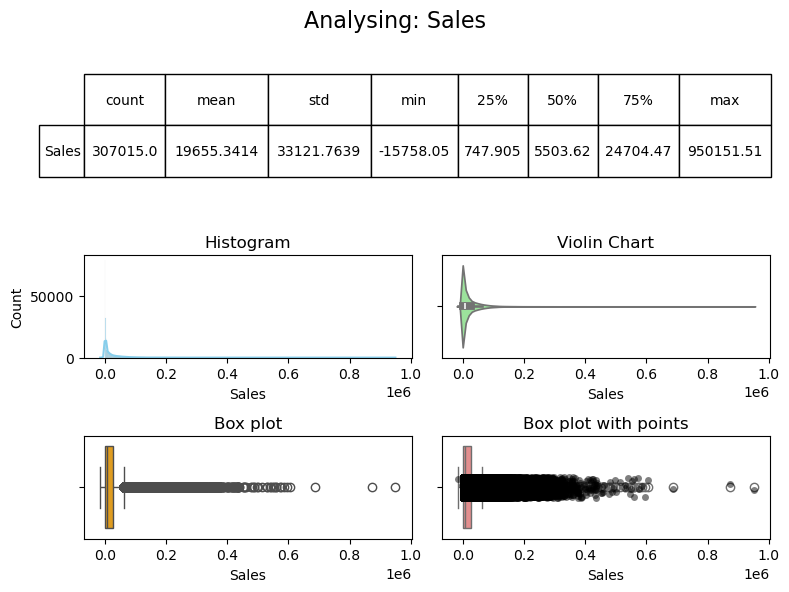

In [363]:
# Variable: Vendas
# Convert from string to float
df["Sales"] = df["Vendas"].str.replace(",", "").astype(float)

# Count total missing/invalid
missing_count = df["Sales"].isna().sum()
print(f"Total missing or errored rows: {missing_count}")

# Filter and display rows where the conversion failed
error_rows = df[df["Sales"].isna()]
print(error_rows[["Vendas", "Sales"]])

# Check the earliest and latest
print(df["Sales"].describe())

univariate_numeric_variable(df, "Sales")

#### <span style="color:green">Variable Sales_adj</span>

count    307015.000000
mean      19655.435832
std       33121.694370
min           0.000000
25%         747.905000
50%        5503.620000
75%       24704.470000
max      950151.510000
Name: Sales_adj, dtype: float64


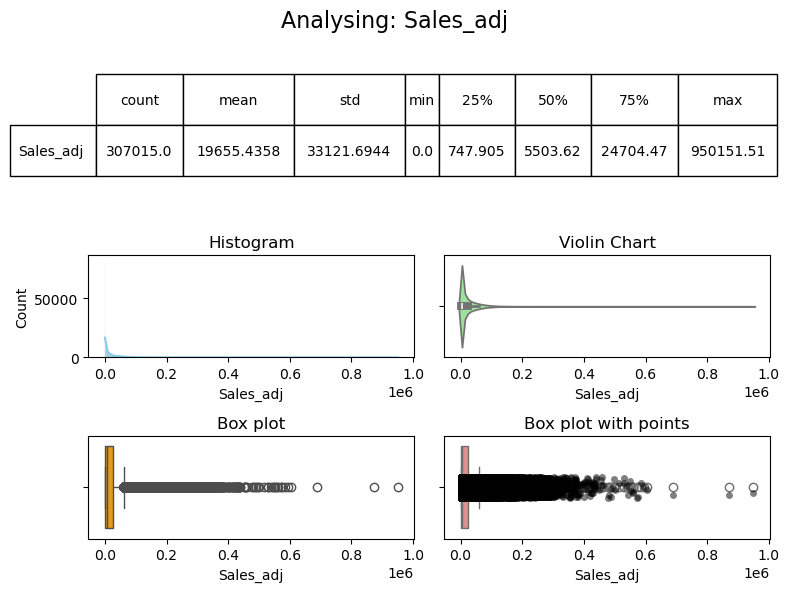

In [364]:
df["Sales_adj"] = df["Sales"].clip(lower=0)

# Check the earliest and latest
print(df["Sales_adj"].describe())

univariate_numeric_variable(df, "Sales_adj")

### <span style="color:green">Variable: Company</span>

- Decided to create a string for each company.
- Note that `Comp_1` is the one that appears the most in the database as `Comp_23` appears the least.

['Comp_1' 'Comp_2' 'Comp_5' 'Comp_15' 'Comp_16' 'Comp_6' 'Comp_13'
 'Comp_12' 'Comp_9' 'Comp_19' 'Comp_18' 'Comp_21' 'Comp_22' 'Comp_23']
Categorical variable describe:


,count,unique,top,freq
Company,307015,14,Comp_1,31095


Frequency table of categorical variable (with percentage and total):


,Company,Frequency,Percentage (%)
0,Comp_1,31095,10.13
1,Comp_9,29106,9.48
2,Comp_2,27960,9.11
3,Comp_19,26106,8.50
4,Comp_18,25373,8.26
5,Comp_15,24840,8.09
6,Comp_16,24746,8.06
7,Comp_5,24664,8.03
8,Comp_12,24512,7.98
9,Comp_13,22759,7.41


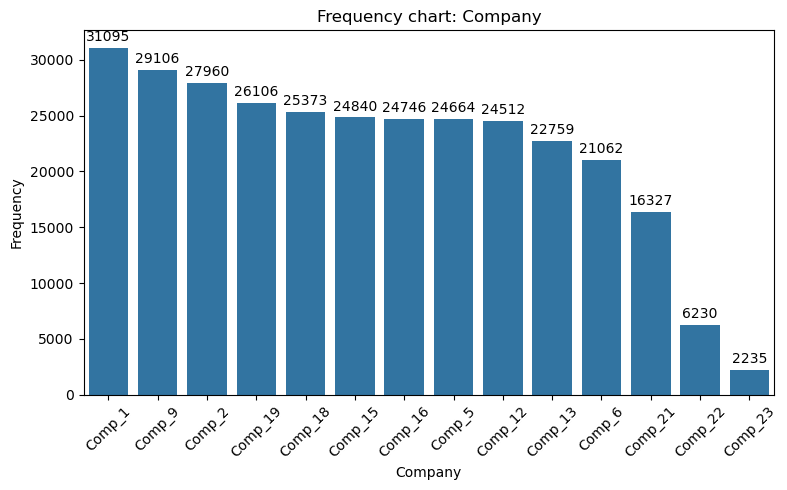

In [365]:
# Variable: Empresa
df["Company"] = "Comp_" + df["Empresa"].astype(str)

print(df["Company"].unique())

univariate_categorical_variable(df, "Company")

### <span style="color:green">Variable: Section</span>

- `Seção 23` is the most frequent one in the database (representing 5.8%).
- `Seção 29` is the least present on the databse with only 14 records.

Categorical variable describe:


,count,unique,top,freq
Seção,307015,29,Seção 23,17827


Frequency table of categorical variable (with percentage and total):


,Seção,Frequency,Percentage (%)
0,Seção 23,17827,5.81
1,Seção 26,12908,4.20
2,Seção 20,12908,4.20
3,Seção 16,12907,4.20
4,Seção 13,12906,4.20
5,Seção 3,12906,4.20
6,Seção 4,12906,4.20
7,Seção 17,12906,4.20
8,Seção 2,12906,4.20
9,Seção 9,12906,4.20


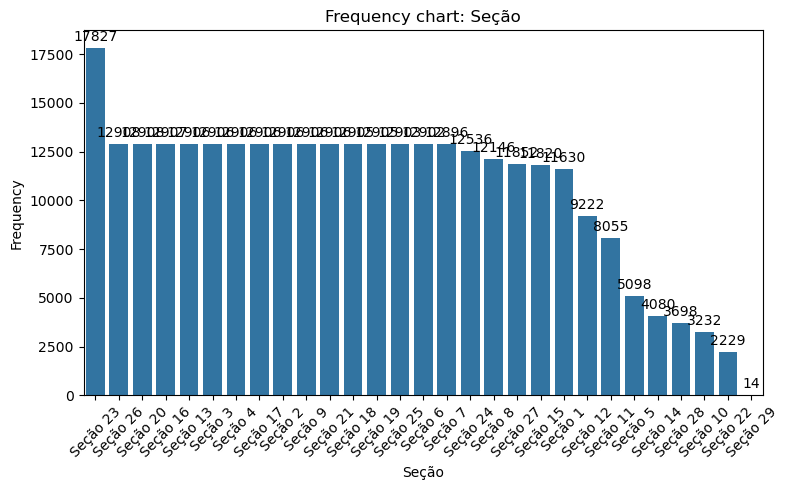

In [366]:
univariate_categorical_variable(df, "Seção")

### <span style="color:green">Variable: Department</span>

- `Depto 3`	is the most frequent, representing 38% of the data.
- `Depto 4` & `Depto 2` represent ~25% of the data
- All other departments are below 10%.


Categorical variable describe:


,count,unique,top,freq
Departamento,307015,7,Depto 3,117115


Frequency table of categorical variable (with percentage and total):


,Departamento,Frequency,Percentage (%)
0,Depto 3,117115,38.15
1,Depto 4,79294,25.83
2,Depto 2,77439,25.22
3,Depto 5,12903,4.20
4,Depto 1,11630,3.79
5,Depto 7,4936,1.61
6,Depto 6,3698,1.20
7,Total,307015,100.00


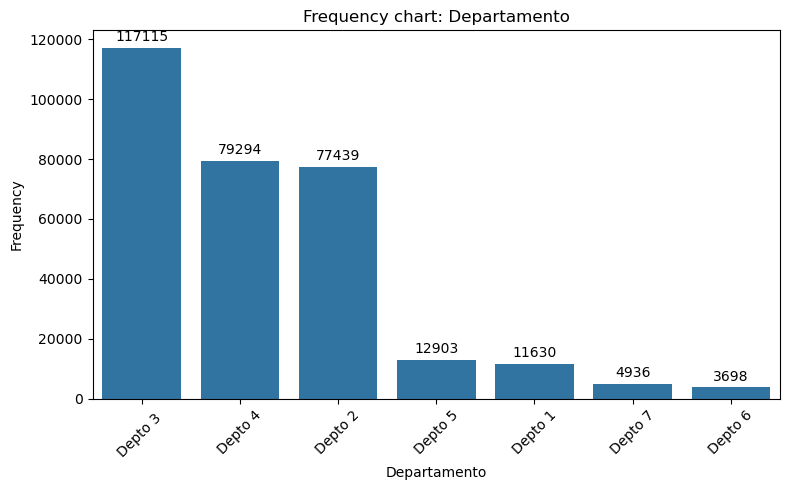

In [367]:
univariate_categorical_variable(df, "Departamento")

### ▫️<span style="color:purple">Section Final Notes</span>

We have looked at each variable separatelly, but each level of combination can give us another directionality of how the data can be used to get the best prediction out of it.

- Company - Department - Section : 
    - Using this combination we can see that not all companies have the same department nor the same sections of number of sections. 
    - The number of days is also not the same.


- Department - Section : 
    - Using this combination we can see that not all departments have the same sections of number of sections.
    - The number of days is also not the same.

Since the initial problem told us to focus on Department 2 or 4, let's group our data athe Department level, and _ignore_ for now Company and Section variables as they seem to split the information too much and can cause noise when forecasting.

In [368]:
df.groupby(['Company', 'Departamento', 'Seção']).size()

Company  Departamento  Seção   
Comp_1   Depto 1       Seção 1     1139
         Depto 2       Seção 16    1139
                       Seção 17    1139
                       Seção 2     1139
                       Seção 26    1139
                                   ... 
Comp_9   Depto 4       Seção 23    1148
                       Seção 24    1148
         Depto 5       Seção 25    1148
         Depto 6       Seção 28     678
         Depto 7       Seção 23     360
Length: 394, dtype: int64

In [369]:
df.groupby(['Departamento', 'Seção']).size()

Departamento  Seção   
Depto 1       Seção 1     11630
Depto 2       Seção 16    12907
              Seção 17    12906
              Seção 2     12906
              Seção 26    12908
              Seção 3     12906
              Seção 4     12906
Depto 3       Seção 10     3232
              Seção 11     8055
              Seção 12     9222
              Seção 13    12906
              Seção 14     4080
              Seção 15    11820
              Seção 27    11852
              Seção 5      5098
              Seção 6     12902
              Seção 7     12896
              Seção 8     12146
              Seção 9     12906
Depto 4       Seção 18    12905
              Seção 19    12905
              Seção 20    12908
              Seção 21    12906
              Seção 22     2229
              Seção 23    12905
              Seção 24    12536
Depto 5       Seção 25    12903
Depto 6       Seção 28     3698
Depto 7       Seção 23     4922
              Seção 29       14
dtype: int64

## 🔸Choosing Department & Aggregating to Daily Level

In [370]:
# aggregate by Department & Date
df_depts = df.groupby(["Departamento", "Date"]).agg({
    'Sales_adj': 'sum',           # Sum sales for the day
    'Feriado': 'max',             # Max flag (1 if any record is holiday, else 0)
    'Pagamento': 'max',
    'Vale': 'max'
}).reset_index()

Categorical variable describe:


,count,unique,top,freq
Departamento,7707,7,Depto 1,1148


Frequency table of categorical variable (with percentage and total):


,Departamento,Frequency,Percentage (%)
0,Depto 1,1148,14.90
1,Depto 2,1148,14.90
2,Depto 3,1148,14.90
3,Depto 4,1148,14.90
4,Depto 5,1148,14.90
5,Depto 7,1147,14.88
6,Depto 6,820,10.64
7,Total,7707,100.00


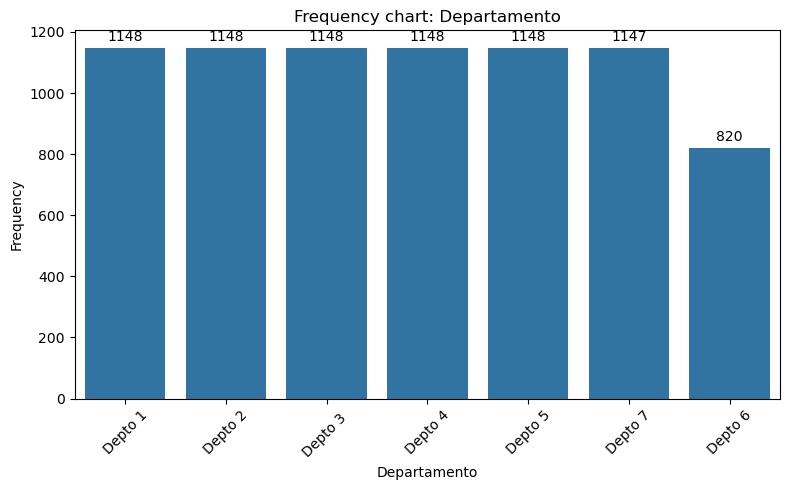

In [371]:
univariate_categorical_variable(df_depts, "Departamento")

# univariate_categorical_variable(df_depts, "Feriado")

# univariate_categorical_variable(df_depts, "Pagamento")

# univariate_categorical_variable(df_depts, "Vale")

# univariate_numeric_variable(df_depts, "Sales_adj")

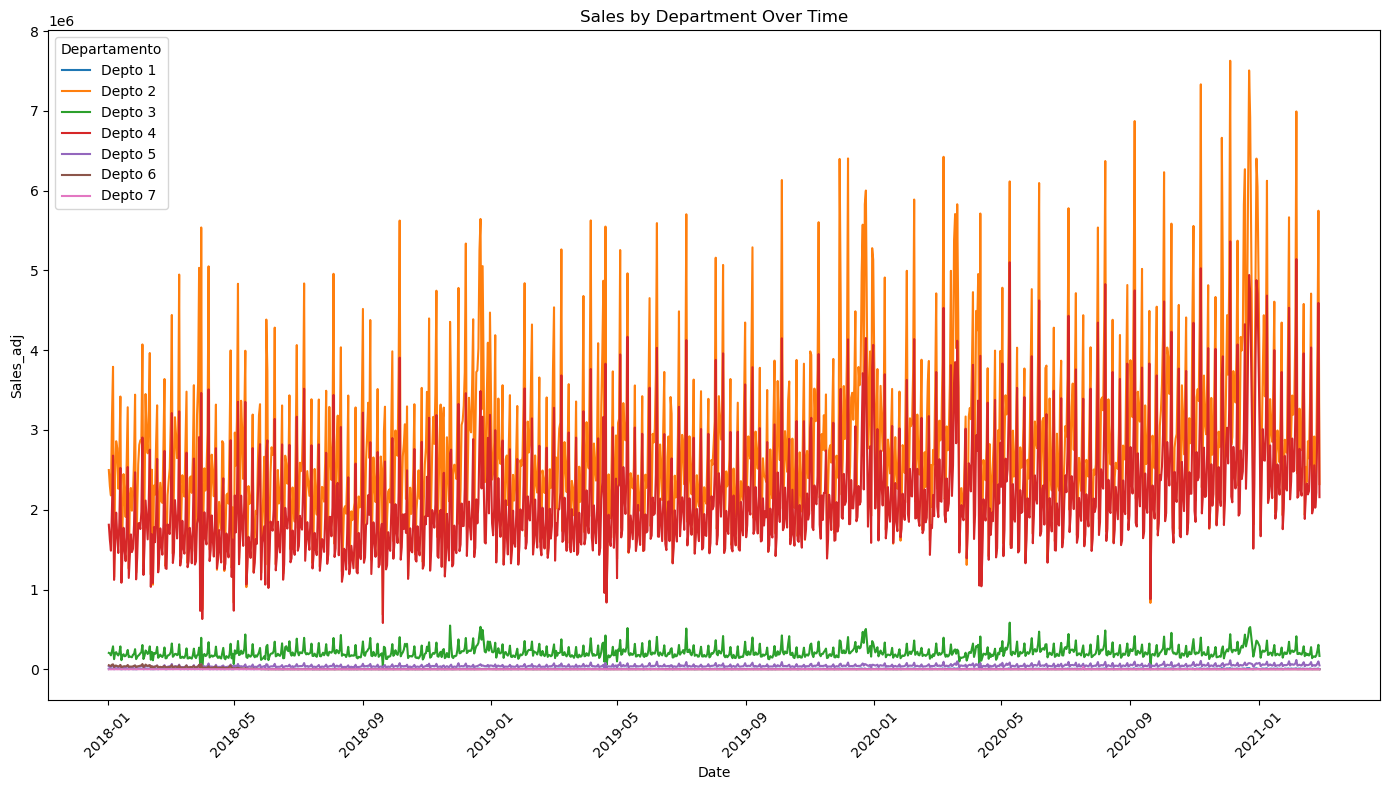

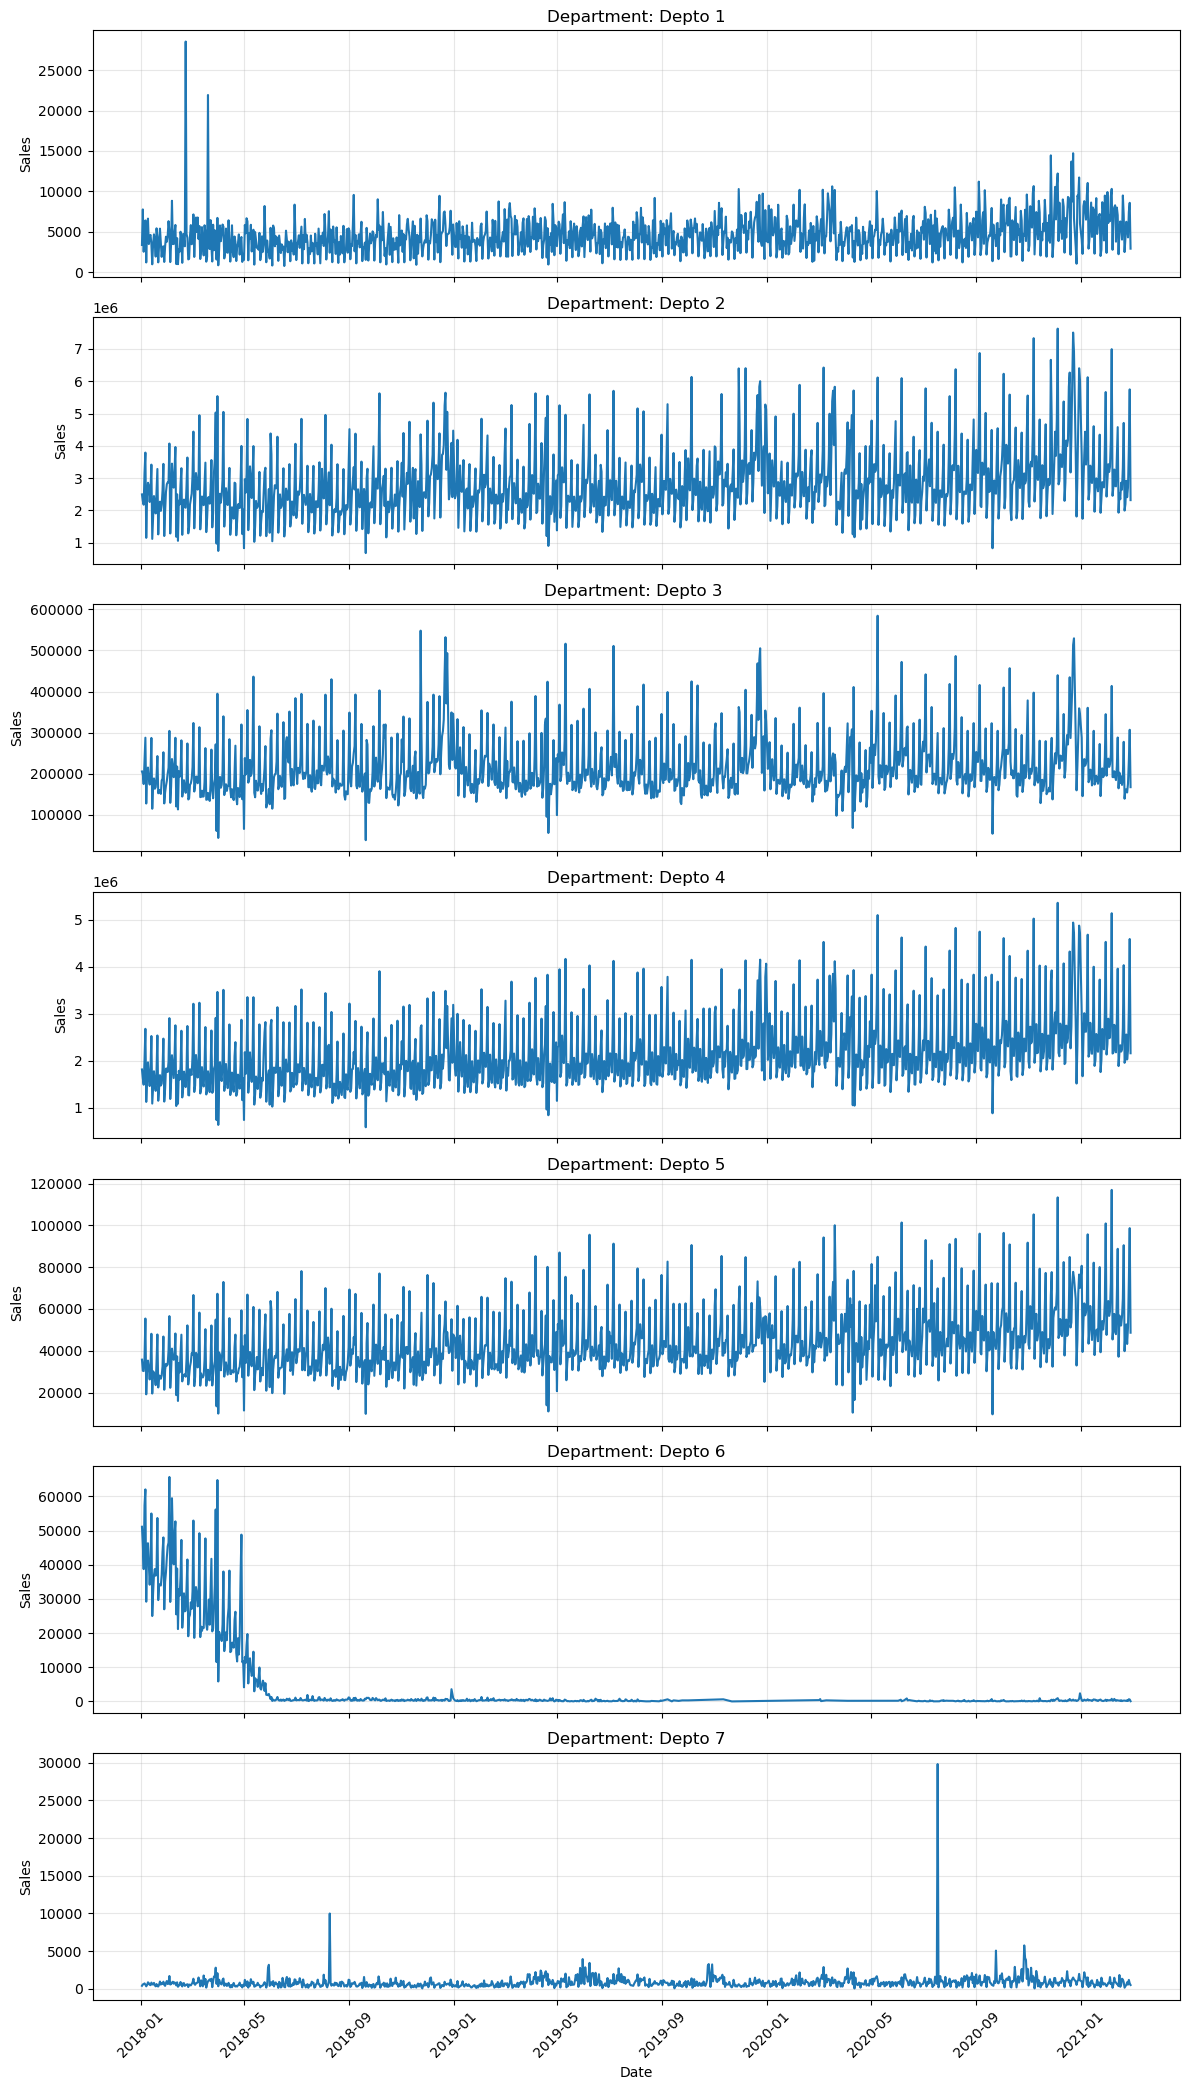

In [372]:
# plot Department & Sales by Date

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_depts, x='Date', y='Sales_adj', hue='Departamento')
plt.title('Sales by Department Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(nrows=len(df_depts['Departamento'].unique()), 
                         figsize=(12, 3*len(df_depts['Departamento'].unique())), 
                         sharex=True)

for ax, (dept, group) in zip(axes, df_depts.groupby('Departamento')):
    ax.plot(group['Date'], group['Sales_adj'], linestyle='-')
    ax.set_title(f'Department: {dept}')
    ax.set_ylabel('Sales')
    ax.grid(True, alpha=0.3)

plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Choose Department

From this moment, we have aggregated Department by dates, and we will now choose a department to focus on.

There is no more Company or Section.

In [373]:
# choosing department
choose_dept = 'Depto 4'
print(f"We will be working with: {choose_dept}")

df_dep = df_depts[df_depts['Departamento'] == choose_dept].copy()

We will be working with: Depto 4


### Input missing dates

We need to create a dataset with all the dates for the period we are going to analyze.


    

In [374]:
# get minimum year
min_year = df_dep['Date'].dt.year.min()

# create start date as Jan 1st of that year
start_date = pd.Timestamp(f'{min_year}-01-01')

# get the end date
end_date = df_dep['Date'].max() 

# create complete date range
all_dates = pd.date_range(start=start_date, end=end_date, freq='D')

# get unique departments
departments = df_dep['Departamento'].unique()

# create all combinations of dates and departments
df_complete = pd.DataFrame(
    [(date, dept) for date in all_dates for dept in departments],
    columns=['Date', 'Departamento']
)

# merge with original data
df_complete = df_complete.merge(df_dep, on=['Date', 'Departamento'], how='left')
df_complete['year_month'] = df_complete['Date'].dt.to_period('M')
df_complete['payment_weekday'] = df_complete['Date'].dt.day_name()



In [375]:
# df_complete

In [376]:
# Analysis on missing dates
df_complete[df_complete["Feriado"].isna()]

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year_month,payment_weekday
0,2018-01-01,Depto 4,NaN,NaN,NaN,NaN,2018-01,Monday
358,2018-12-25,Depto 4,NaN,NaN,NaN,NaN,2018-12,Tuesday
365,2019-01-01,Depto 4,NaN,NaN,NaN,NaN,2019-01,Tuesday
723,2019-12-25,Depto 4,NaN,NaN,NaN,NaN,2019-12,Wednesday
730,2020-01-01,Depto 4,NaN,NaN,NaN,NaN,2020-01,Wednesday
1089,2020-12-25,Depto 4,NaN,NaN,NaN,NaN,2020-12,Friday
1096,2021-01-01,Depto 4,NaN,NaN,NaN,NaN,2021-01,Friday


#### ▪️<span style="color:purple">Notes</span>

Every missing date was new year and christmas!

- **Question**
    - _This might mean that there were never sales on this dates possibly because they don't open?_
    - _Can we create a flag to indicate that there will never be sales that day for the future?_

#### Variable: isClosed

Let's create a flag for the missing dates in the original dataset, because these dates will alsys be missing in the future.

- Happens on every Dec-25 and Jan-01

In [377]:
df_complete['isClosed'] = ((df_complete['Date'].dt.month == 12) & (df_complete['Date'].dt.day == 25)) | \
                          ((df_complete['Date'].dt.month == 1) & (df_complete['Date'].dt.day == 1))

df_complete['isClosed'] = df_complete['isClosed'].astype(int) 

In [378]:
# Assign 0 to the other variables

df_complete['Feriado'] = df_complete['Feriado'].fillna(0)    
df_complete['Pagamento'] = df_complete['Pagamento'].fillna(0)
df_complete['Vale'] = df_complete['Vale'].fillna(0)
df_complete['Sales_adj'] = df_complete['Sales_adj'].fillna(0)

### Variable: Feriado

#### <span style="color:purple">External Dataset:</span> `holidays.csv`

To enable accurate mapping of holiday flags for future dates, we sourced Brazilian holiday data from the [Feriados API](https://feriadosapi.com/docs#introducao). 
This external dataset provides a standardized reference for holidays across different periods and allows us to systematically evaluate how holidays are represented in our time series.


Dictionary


| #   | Variable    | Description                                                                                                                  | Type                  | Raw | Notes |
| --- | ----------- | ---------------------------------------------------------------------------------------------------------------------------- | --------------------- | --- | ----- |
| 1   | id          | unique ID of holiday date                                                                                                    | Qualitative Nominal   | Y   |       |
| 2   | data        | Holiday date, format `DD/MM/YYYY`                                                                                            | Date                  | Y   |       |
| 3   | nome        | Holiday name                                                                                                                 | Qualitative Nominal   | Y   |       |
| 4   | tipo        | Which holiday databse the holiday was extracted: National / State / State Capital<br>`NACIONAL` /  `ESTADUAL` /  `MUNICIPAL` | Qualitative Nominal   | Y   |       |
| 5   | descricao   | Holiday descriptive long                                                                                                     | Qualitative Nominal   | Y   |       |
| 6   | uf          | Brazilian State. <br>Only present in **tipo** = `ESTADUAL` /  `MUNICIPAL`                                                    | Qualitative Nominal   | Y   |       |
| 7   | codigo_ibge | City code according to IBGE.<br>Only present in **tipo** =  `MUNICIPAL`<br>                                                  | Qualitative Nominal   | Y   |       |
| 8   | bancario    | Flag for a bank holiday                                                                                                      | Qualitative Binary    | Y   |       |
| 9   | year        | Holiday date year extracted.                                                                                                 | Quantitative Discrete | Y   |       |
| 10  | type        | same as `tipo`<br>`national` /  `state` /  `capital`                                                                         | Qualitative Nominal   | Y   |       |
| 11  | state       | same as `uf`                                                                                                                 | Qualitative Nominal   | Y   |       |
| 12  | ibge_code   | same as `codigo_ibge`                                                                                                        | Qualitative Nominal   | Y   |       |
| 13  | Date        | Convert from a regular english date format `YYYY-MM-DD`                                                                      | Date                  | N   |       |




In [379]:
df_holiday["Date"] = pd.to_datetime(df_holiday["data"], format='%d/%m/%Y', errors='coerce')
# df_holiday.head()
# df_holiday[df_holiday["Date"] == '2019-10-12']

df_holiday_simple = df_holiday[["Date", "nome"]].copy()
df_holiday_unique = df_holiday_simple.drop_duplicates(subset=['Date'], keep='first')

# df_holiday_simpleSP = df_holiday_simple[df_holiday_simple["state"] == 'SP'].copy()
# df_holiday_simpleSP.head()

# Check if there are any duplicate dates
has_duplicates = df_holiday_unique['Date'].duplicated().any()
print(f"Are there duplicate dates? {has_duplicates}")

# See which dates are duplicated
duplicate_dates = df_holiday_unique[df_holiday_unique['Date'].duplicated(keep=False)]
print("Duplicate dates:")
print(duplicate_dates['Date'].value_counts())



Are there duplicate dates? False
Duplicate dates:
Series([], Name: count, dtype: int64)


In [380]:
df_complete1 = df_complete.merge(df_holiday_unique, on=['Date'], how='left')

In [381]:
df_map_holidays = df_complete1[df_complete1["Feriado"] == 1]

print(f"Total holidays in the database: {df_map_holidays.shape}")
print(f"Holidays missing description: {df_map_holidays[df_map_holidays["nome"].isna()].shape}")

Total holidays in the database: (43, 10)
Holidays missing description: (0, 10)


#### Investigating `Feriado = 1` records **without** a holiday description

Records where the holiday indicator is active (`Feriado = 1`) but no holiday name is provided.  
We examine the frequency of these cases, their distribution over time, and potential impact on the time series analysis.

In [382]:
df_map_holidays[df_map_holidays["nome"].isna()]

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year_month,payment_weekday,isClosed,nome


#### Investigating `Feriado = 1` records **with** a holiday description

Records where the holiday indicator is active (`Feriado = 1`) and a holiday name is provided.  
We examine the unique holidays, their occurrence counts, and temporal patterns to better understand their potential impact on the series.

In [383]:
# what are the holidays being correctly flag?
df_map_holidays.groupby(['nome']).size()

nome
Aniversário da Cidade de São Paulo              4
Carnaval                                        4
Carnaval (Segunda-feira)                        4
Corpus Christi                                  3
Dia Mundial do Trabalho                         3
Dia Nacional de Zumbi e da Consciência Negra    2
Dia da Consciência Negra                        1
Dia de Finados                                  2
Dia de Tiradentes                               3
Finados                                         1
Imaculada Conceição                             3
Independência do Brasil                         3
Nossa Senhora Aparecida                         3
Proc. República Rio Grandense                   1
Proclamação da República                        3
Sexta-Feira Santa                               1
Sexta-feira Santa                               2
dtype: int64

#### Investigating `Feriado = 0` records **with** a holiday description

These records have the holiday flag set to 0, yet a holiday name/description is present.  
This may reflect the granularity of the holiday dataset, for example, local or small-city holidays that do not significantly affect main businesses and are therefore not flagged as relevant.  
This section checks how frequent these cases are, which holidays appear, and whether they should be treated as data quality issues or expected behavior.

In [384]:
# what are the non holidays that has description?
df_map_NOTholidays = df_complete1[df_complete1["Feriado"] == 0]
df_map_NOTholidays.groupby(['nome']).size()

nome
Aniversário de Florianópolis                 3
Ano Novo                                     4
Assunção de Nossa Senhora                    3
Dia de Santa Catarina                        3
Dia de São Jorge                             3
Dia de São Sebastião, Padroeiro da cidade    4
Dia do Evangélico                            3
Natal                                        3
Nossa Senhora da Luz dos Pinhais             3
Nossa Senhora da Penha                       3
Nossa Senhora dos Navegantes                 4
Proc. República Rio Grandense                2
Revolução Constitucionalista de 1932         3
dtype: int64

#### Inconsistent holiday flags: same date marked as both holiday and non-holiday

We investigate cases where the same calendar day appears with `Feriado = 1` in some years and `Feriado = 0` in others.  
This analysis helps detect possible inconsistencies in the holiday dataset or differences in how holidays were recorded over time.

In [385]:
# Check if any holiday names have inconsistent flags
inconsistent_holidays = df_complete1.groupby('nome')['Feriado'].nunique()
inconsistent_holidays = inconsistent_holidays[inconsistent_holidays > 1].index.tolist()

print(f"Holidays with inconsistent flags: {len(inconsistent_holidays)}")
print(inconsistent_holidays)

# View the actual inconsistencies
df_inconsistent = df_complete1[df_complete1['nome'].isin(inconsistent_holidays)]
df_inconsistent[['Date', 'nome', 'Feriado']].sort_values(['nome', 'Date'])

Holidays with inconsistent flags: 1
['Proc. República Rio Grandense']


,Date,nome,Feriado
262,2018-09-20,Proc. República Rio Grandense,0.0
627,2019-09-20,Proc. República Rio Grandense,1.0
993,2020-09-20,Proc. República Rio Grandense,0.0


In [386]:
# df_complete1[df_complete1['nome'] == "Proc. República Rio Grandense"]

In [387]:
# df_holiday[df_holiday['Date'] == '2019-09-20']

#### 📌 <span style="color:red">RULE</span>: Future Holiday Flagging

**Key Learnings**:
- Holiday descriptions are consistent and mappable.
    - All holidays in the dataset can be linked to a descriptive name (`nome` field). 
    - This makes it feasible to use these descriptions as a reliable reference for flagging holidays in future data.

- Non-holiday descriptions require caution.
    - Some descriptions appear in the dataset but were not flagged as holidays (`Feriado = 0`). 
    - This may be due to regional variations—certain holidays are only observed in specific cities or states, rather than nationally. 
    - These cases should be treated with care when applying the flag to future periods.

- Inconsistent holiday flagging observed for certain events.
    - The holiday _"Proc. República Rio Grandense"_ was flagged as a holiday (`Feriado = 1`) in 2019, but not in 2018 or 2020. 
    - This inconsistency raises questions about whether this event should be considered a holiday in future predictions.
    - **Decision**: For now, we will assume this holiday as NOT a holiday (`Feriado = 0`) when mapping future dates, unless additional context or data suggests otherwise.

In [388]:
holiday_descriptions = df_map_holidays.groupby(['nome']).size()

holiday_descriptions


nome
Aniversário da Cidade de São Paulo              4
Carnaval                                        4
Carnaval (Segunda-feira)                        4
Corpus Christi                                  3
Dia Mundial do Trabalho                         3
Dia Nacional de Zumbi e da Consciência Negra    2
Dia da Consciência Negra                        1
Dia de Finados                                  2
Dia de Tiradentes                               3
Finados                                         1
Imaculada Conceição                             3
Independência do Brasil                         3
Nossa Senhora Aparecida                         3
Proc. República Rio Grandense                   1
Proclamação da República                        3
Sexta-Feira Santa                               1
Sexta-feira Santa                               2
dtype: int64

##### Holidays to be used for Holiday Flag

In [389]:
# Get the list of holiday names from holiday_descriptions
holiday_names = holiday_descriptions.index.tolist()

# Filter the main dataframe
df_holiday_filtered = df_holiday_unique[df_holiday_unique['nome'].isin(holiday_names)]

df_holiday_filtered

,Date,nome
9,2018-01-25,Aniversário da Cidade de São Paulo
11,2018-02-12,Carnaval (Segunda-feira)
12,2018-02-13,Carnaval
14,2018-03-30,Sexta-feira Santa
29,2018-04-21,Dia de Tiradentes
39,2018-05-01,Dia Mundial do Trabalho
47,2018-05-31,Corpus Christi
58,2018-09-07,Independência do Brasil
68,2018-09-20,Proc. República Rio Grandense
69,2018-10-12,Nossa Senhora Aparecida


### Variable: Pagamento

In [390]:
# Add .reset_index(name='count') at the end of line 1
df_pgto = df_complete[df_complete['Pagamento'] == 1].copy()
check_payday = df_pgto.groupby(['Date']).size().reset_index(name='count')

# Now 'Date' is a normal column, so this will work perfectly
check_payday["Date"] = pd.to_datetime(check_payday["Date"])

# Extract your weekday columns
check_payday["day_name"] = check_payday["Date"].dt.day_name()
check_payday["day_num"] = check_payday["Date"].dt.weekday

check_payday

,Date,count,day_name,day_num
0,2018-01-05,1,Friday,4
1,2018-02-06,1,Tuesday,1
2,2018-02-07,1,Wednesday,2
3,2018-03-06,1,Tuesday,1
4,2018-04-06,1,Friday,4
5,2018-05-07,1,Monday,0
6,2018-06-06,1,Wednesday,2
7,2018-07-06,1,Friday,4
8,2018-08-06,1,Monday,0
9,2018-09-06,1,Thursday,3


#### Day of the Month

Checking what is the most frequent **day of the month** payment day is likely to fall.

- Higher frequency on 6th and 7th
- Ranges between 4 to 8, mening that is likely to fall on the first week of the month
- **Question**:
    - _Would day of the week be more consistent?_

In [391]:
# Extract the day number of the month (e.g., 5, 6, 7)
check_payday["day_of_month"] = check_payday["Date"].dt.day

# Count how many times each day of the month appears
payday_frequencies = check_payday.groupby("day_of_month").size().reset_index(name="payment_count")

# Sort by the highest frequency to see the dominant day
payday_frequencies = payday_frequencies.sort_values(by="payment_count", ascending=False)

print("\nPayment frequency per day of month:")
print(payday_frequencies)



Payment frequency per day of month:
   day_of_month  payment_count
2             6             20
3             7             10
1             5              6
0             4              3
4             8              1


#### Day of the Week

Checking now for **day of the week**.

- Friday has a higher frquency
- Payment is **never** on a weekend
- **Question**:
    - _Any reason to not be on a friday only?_


In [392]:
# Count how many times each day appears
payday_frequencies2 = check_payday.groupby("day_name").size().reset_index(name="payment_count")

# Sort by the highest frequency to see the dominant day
payday_frequencies2 = payday_frequencies2.sort_values(by="payment_count", ascending=False)

print("\nPayment frequency per week day:")
print(payday_frequencies2)


Payment frequency per week day:
    day_name  payment_count
0     Friday             16
2   Thursday              8
1     Monday              6
3    Tuesday              6
4  Wednesday              4


#### Day of Month, Day of Week, Holiday, Payment and isClosed

- Payment on the 6th is more frequent than being on a Friday. 
- **Questions** 
    - _If 6th in on a weekend, was payment move to the 7th?_
        - Only when the 6th falls on a SUNDAY. 
            - If 6th is Saturday → Payment moves to Friday (5th)
            - If 6th is Sunday → Payment moves to Monday (7th)

    - _If the 6th is a holiday, did payment move to the 7th?_
        - No. Holidays typically move payment to the PREVIOUS business day.
            - If 6th is a Friday holiday → Payment moves to Thursday (4th)
            - If 6th is a Sunday and 7th (Monday) is also a holiday → Payment moves to Tuesday (8th)

    - _How many business days are from the begining of the month to payment day not counting holidays and closed days (where there was no sales)?_
        - The payment typically happens on the 5th business day of the month.
        - Frequency breakdown:
            - 3 business days: 28 months (70%) ← MOST COMMON
            - 4 business days: 12 months (30%)




In [393]:
# Get payment days only
payments = df_complete[df_complete['Pagamento'] == 1].copy()
payments['Date'] = pd.to_datetime(payments['Date'])
payments['day_of_month'] = payments['Date'].dt.day
payments['month'] = payments['Date'].dt.month
payments['year'] = payments['Date'].dt.year

# For each payment, get the first business day of that month
# First, get all business days (not weekend, not Feriado, not isClosed)
df_complete['is_business_day'] = (
    (df_complete['Date'].dt.weekday < 5) &  # Monday-Friday
    (df_complete['Feriado'] != 1) &
    (df_complete['isClosed'] != 1)
)

# For each month, find the first business day
first_biz_days = df_complete[df_complete['is_business_day']].groupby('year_month')['Date'].min().reset_index()
first_biz_days.columns = ['year_month', 'first_business_day']

# Merge with payments
payments = payments.merge(first_biz_days, on='year_month', how='left')

# For each payment, count Feriado and isClosed in the period
def count_flags(row):
    mask = (df_complete['Date'] >= row['first_business_day']) & (df_complete['Date'] <= row['Date'])
    period_data = df_complete[mask]
    return pd.Series({
        'feriado_count': period_data['Feriado'].sum(),
        'closed_count': period_data['isClosed'].sum(),
        'weekend_count': (period_data['Date'].dt.weekday >= 5).sum()
    })

# Apply the function to get counts
counts = payments.apply(count_flags, axis=1)
payments = pd.concat([payments, counts], axis=1)

# Calculate days from first business day
payments['days_from_first_biz'] = (payments['Date'] - payments['first_business_day']).dt.days - payments['weekend_count']
payments['biz_days_from_first_biz'] = payments['days_from_first_biz'] - payments['feriado_count'] - payments['closed_count']

# Add total days in the month
payments['total_days_in_month'] = payments['Date'].dt.days_in_month

# Add total business days in the month (excluding weekends, Feriado, isClosed)
def count_total_biz_days(row):
    year = row['year']
    month = row['month']
    start_date = pd.Timestamp(year=year, month=month, day=1)
    end_date = start_date + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start=start_date, end=end_date)
    
    biz_count = 0
    for d in month_dates:
        day_data = df_complete[df_complete['Date'] == d]
        if len(day_data) > 0:
            if d.weekday() < 5 and day_data['Feriado'].values[0] != 1 and day_data['isClosed'].values[0] != 1:
                biz_count += 1
    return biz_count

payments['total_biz_days_in_month'] = payments.apply(count_total_biz_days, axis=1)

# Create final result table
result_df = payments[['year_month', 'day_of_month', 'first_business_day', 'payment_weekday', 
                      'feriado_count', 'closed_count', 'weekend_count', 'days_from_first_biz', 
                      'biz_days_from_first_biz', 'total_days_in_month', 'total_biz_days_in_month']].copy()
result_df.columns = ['Month', 'Payment_Day', 'First_Business_Day', 'Payment_Weekday', 
                     'Feriado_Count', 'isClosed_Count', 'Weekend_Count', 'Days_From_First_Biz', 
                     'Biz_Days_From_First_Biz', 'Total_Days_In_Month', 'Total_Biz_Days_In_Month']

print("\nPAYMENT ANALYSIS TABLE")
print("\n" + "="*100)
print(result_df.to_string(index=False))
print("="*100)



PAYMENT ANALYSIS TABLE

  Month  Payment_Day First_Business_Day Payment_Weekday  Feriado_Count  isClosed_Count  Weekend_Count  Days_From_First_Biz  Biz_Days_From_First_Biz  Total_Days_In_Month  Total_Biz_Days_In_Month
2018-01            5         2018-01-02          Friday            0.0             0.0            0.0                  3.0                      3.0                   31                       21
2018-02            6         2018-02-01         Tuesday            0.0             0.0            2.0                  3.0                      3.0                   28                       18
2018-02            7         2018-02-01       Wednesday            0.0             0.0            2.0                  4.0                      4.0                   28                       18
2018-03            6         2018-03-01         Tuesday            0.0             0.0            2.0                  3.0                      3.0                   31                       21
2018-

In [394]:
# Frequency of business days from first business day
print("FREQUENCY OF BUSINESS DAYS FROM FIRST BUSINESS DAY")
freq_biz_days = payments.groupby('biz_days_from_first_biz').size().reset_index(name='count')
freq_biz_days.columns = ['Business_Days', 'Number_of_Months']
print(freq_biz_days.sort_values('Number_of_Months', ascending=False).to_string(index=False))

FREQUENCY OF BUSINESS DAYS FROM FIRST BUSINESS DAY
 Business_Days  Number_of_Months
           3.0                28
           4.0                12


In [395]:
print("PAYMENT BUSINESS DAYS BY BUSINESS MONTH SIZE")
print(result_df.groupby('Total_Biz_Days_In_Month')['Biz_Days_From_First_Biz'].value_counts().unstack(fill_value=0))

PAYMENT BUSINESS DAYS BY BUSINESS MONTH SIZE
Biz_Days_From_First_Biz  3.0  4.0
Total_Biz_Days_In_Month          
18                         2    2
19                         7    0
20                         4    1
21                         9    5
22                         3    3
23                         3    1


In [396]:
print("PAYMENT BUSINESS DAYS BY MONTH SIZE")
print(result_df.groupby('Total_Days_In_Month')['Biz_Days_From_First_Biz'].value_counts().unstack(fill_value=0))

PAYMENT BUSINESS DAYS BY MONTH SIZE
Biz_Days_From_First_Biz  3.0  4.0
Total_Days_In_Month              
28                         2    2
29                         1    0
30                         8    4
31                        17    6


#### 📌<span style="color:red">RULE</span>: Future Payment Days

> Pay on the 3rd or 4th business day of the month, counting from the first business day and excluding weekends, holidays, and closed days.

1. Pay on the 3rd or 4th business day from the first business day of the month
2. Business days = Weekdays (Monday-Friday) that are NOT Feriado and NOT isClosed
3. The 6th calendar day is the target, but only if it falls on the 3rd or 4th business day
4. If the 6th is a Saturday → Pay on the 5th (Friday)
5. If the 6th is a Sunday → Pay on the 7th (Monday)
6. If the 6th is a holiday or closed → Pay on the previous business day
7. If the adjusted day (from rules 4-6) is also a holiday or closed → Move to the previous business day
8. If the 6th falls on a weekday but is only the 2nd business day from the first business day → Move to the 7th or 8th to reach the 3rd or 4th business day



In [397]:
def get_payment_date(year, month, df_complete):
    """
    Returns the 4th business day of the month
    Business day = not weekend, not Feriado, not isClosed
    """
    # Get all dates in the month
    start_date = pd.Timestamp(year=year, month=month, day=1)
    end_date = start_date + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start=start_date, end=end_date)
    
    # Create a dictionary for quick lookup of Feriado and isClosed
    date_dict = {}
    for _, row in df_complete.iterrows():
        date_dict[row['Date']] = {
            'Feriado': row['Feriado'],
            'isClosed': row['isClosed']
        }
    
    # Find business days
    biz_days = []
    for d in month_dates:
        # Skip weekends
        if d.weekday() >= 5:
            continue
        
        # Check if we have data for this day
        if d not in date_dict:
            continue
        
        # Skip if Feriado or isClosed
        if date_dict[d]['Feriado'] == 1 or date_dict[d]['isClosed'] == 1:
            continue
        
        biz_days.append(d)
    
    # Return the 4th business day (index 3)
    if len(biz_days) >= 4:
        return biz_days[3]  # 4th business day
    else:
        print(f"Warning: Only {len(biz_days)} business days found for {year}-{month:02d}")
        return None

# Test for a specific month
print("Testing January 2018:")
test_date = get_payment_date(2018, 1, df_complete)
print(f"Calculated: {test_date}")  # Should be 2018-01-05

print("\nTesting February 2018:")
test_date = get_payment_date(2018, 2, df_complete)
print(f"Calculated: {test_date}")  # Should be 2018-02-06

# Usage
# payment_date = get_payment_date(2021, 1, df_complete)
# print(f"Payment should be on: {payment_date}")

Testing January 2018:
Calculated: 2018-01-05 00:00:00

Testing February 2018:
Calculated: 2018-02-06 00:00:00


In [398]:
# Store all payment dates in a DataFrame
results_payday_range = []
for year in range(2018, 2022):
    for month in range(1, 13):
        payment_date = get_payment_date(year, month, df_complete)
        if payment_date:
            results_payday_range.append({
                'year': year,
                'month': month,
                'payment_date': payment_date,
                'day_of_month': payment_date.day,
                'weekday': payment_date.strftime('%A')
            })

results_payday_range_df = pd.DataFrame(results_payday_range)
results_payday_range_df

,year,month,payment_date,day_of_month,weekday
0,2018,1,2018-01-05,5,Friday
1,2018,2,2018-02-06,6,Tuesday
2,2018,3,2018-03-06,6,Tuesday
3,2018,4,2018-04-05,5,Thursday
4,2018,5,2018-05-07,7,Monday
5,2018,6,2018-06-06,6,Wednesday
6,2018,7,2018-07-05,5,Thursday
7,2018,8,2018-08-06,6,Monday
8,2018,9,2018-09-06,6,Thursday
9,2018,10,2018-10-04,4,Thursday


In [399]:
df_complete = df_complete.merge(results_payday_range_df[['payment_date']], left_on='Date', right_on='payment_date', how='left')

# Add flags
df_complete['is_calculated_payment_day'] = df_complete['Date'] == df_complete['payment_date']
df_complete['payment_matches_rule'] = (df_complete['Pagamento'] == 1) & (df_complete['is_calculated_payment_day'] == True)

df_complete

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year_month,payment_weekday,isClosed,is_business_day,payment_date,is_calculated_payment_day,payment_matches_rule
0,2018-01-01,Depto 4,0.00,0.0,0.0,0.0,2018-01,Monday,1,False,NaT,False,False
1,2018-01-02,Depto 4,1812134.19,0.0,0.0,0.0,2018-01,Tuesday,0,True,NaT,False,False
2,2018-01-03,Depto 4,1622115.60,0.0,0.0,0.0,2018-01,Wednesday,0,True,NaT,False,False
3,2018-01-04,Depto 4,1486888.42,0.0,0.0,0.0,2018-01,Thursday,0,True,NaT,False,False
4,2018-01-05,Depto 4,2015469.36,0.0,1.0,0.0,2018-01,Friday,0,True,2018-01-05,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1150,2021-02-24,Depto 4,2025751.85,0.0,0.0,0.0,2021-02,Wednesday,0,True,NaT,False,False
1151,2021-02-25,Depto 4,2216224.47,0.0,0.0,1.0,2021-02,Thursday,0,True,NaT,False,False
1152,2021-02-26,Depto 4,3098829.40,0.0,0.0,0.0,2021-02,Friday,0,True,NaT,False,False
1153,2021-02-27,Depto 4,4592539.97,0.0,0.0,0.0,2021-02,Saturday,0,False,NaT,False,False


#### ▪️<span style="color:purple">Note</span>

We have 2 months that had 2 payment days 2018-Feb and 2019-Dec. The rule created was able to get one of the days correct ans since we will be just predicting one payment day for month, we will assume the model was correct.

This way, the rule is able to capture more than 75% of the paydays so we will move with this rule to find future paydays.

|              | overall count | counts with no duplicates |
| ------------ | ------------- | ------------------------- |
| Matches rule | 27 (67.5%)    | 29 (76%)                  |
| Mismatches   | 13 (32.5%)    | 9 (24%)                   |
| Total        | 40            | 38                        |


In [400]:
# Filter and count matches
payment_actual = df_complete[df_complete['Pagamento'] == 1]  # Actual payments
payment_calculated = df_complete[df_complete['is_calculated_payment_day'] == True]  # Calculated payment days

# Count matches and mismatches
total_payments = len(payment_actual)
matches = len(payment_actual[payment_actual['is_calculated_payment_day'] == True])
mismatches = total_payments - matches

print(f"Total payments: {total_payments}")
print(f"Matches rule: {matches} ({matches/total_payments*100:.1f}%)")
print(f"Mismatches: {mismatches} ({mismatches/total_payments*100:.1f}%)")

# Show mismatches
print("\nMISMATCHES")
mismatch_df = payment_actual[payment_actual['is_calculated_payment_day'] == False]
print(mismatch_df[['Date', 'Pagamento', 'payment_date']].to_string(index=False))

# Show matches
print("\nMATCHES")
match_df = payment_actual[payment_actual['is_calculated_payment_day'] == True]
print(match_df[['Date', 'Pagamento', 'payment_date']].to_string(index=False))

Total payments: 40
Matches rule: 27 (67.5%)
Mismatches: 13 (32.5%)

MISMATCHES
      Date  Pagamento payment_date
2018-02-07        1.0          NaT
2018-04-06        1.0          NaT
2018-07-06        1.0          NaT
2018-10-05        1.0          NaT
2019-04-05        1.0          NaT
2019-07-05        1.0          NaT
2019-09-06        1.0          NaT
2019-11-07        1.0          NaT
2019-12-06        1.0          NaT
2020-03-06        1.0          NaT
2020-06-05        1.0          NaT
2020-12-07        1.0          NaT
2021-02-05        1.0          NaT

MATCHES
      Date  Pagamento payment_date
2018-01-05        1.0   2018-01-05
2018-02-06        1.0   2018-02-06
2018-03-06        1.0   2018-03-06
2018-05-07        1.0   2018-05-07
2018-06-06        1.0   2018-06-06
2018-08-06        1.0   2018-08-06
2018-09-06        1.0   2018-09-06
2018-11-07        1.0   2018-11-07
2018-12-06        1.0   2018-12-06
2019-01-07        1.0   2019-01-07
2019-02-06        1.0   2019-02-06
20

In [401]:
# check if any rule was missed when the rule
# print(df_complete[((df_complete['Pagamento'] == 1) | (df_complete['is_calculated_payment_day'] == True)) & (df_complete['payment_matches_rule'] == False)])

In [402]:
# df_complete[df_complete['year_month'] == '2021-02'].head(10)

### Variable: Vale


In [403]:
df_vale = df_complete[df_complete['Vale'] == 1].copy()
check_vale = df_vale.groupby(['Date']).size().reset_index(name='count')

# Now 'Date' is a normal column, so this will work perfectly
check_payday["Date"] = pd.to_datetime(check_vale["Date"])

# Extract your weekday columns
check_vale["day_name"] = check_vale["Date"].dt.day_name()
check_vale["day_num"] = check_vale["Date"].dt.weekday

check_vale

,Date,count,day_name,day_num
0,2018-01-24,1,Wednesday,2
1,2018-02-26,1,Monday,0
2,2018-02-27,1,Tuesday,1
3,2018-03-23,1,Friday,4
4,2018-04-25,1,Wednesday,2
5,2018-05-24,1,Thursday,3
6,2018-06-23,1,Saturday,5
7,2018-07-24,1,Tuesday,1
8,2018-08-23,1,Thursday,3
9,2018-09-25,1,Tuesday,1


In [404]:
# Extract the day number of the month (e.g., 5, 6, 7)
check_vale["day_of_month"] = check_vale["Date"].dt.day

# Count how many times each day of the month appears
vale_frequencies = check_vale.groupby("day_of_month").size().reset_index(name="vale_count")

# Sort by the highest frequency to see the dominant day
vale_frequencies = vale_frequencies.sort_values(by="vale_count", ascending=False)

print("\nVale frequency per day of month:")
print(vale_frequencies)



Vale frequency per day of month:
   day_of_month  vale_count
1            24          17
3            26          10
2            25           9
0            23           8
4            27           3


In [405]:
# Count how many times each day appears
vale_frequencies2 = check_vale.groupby("day_name").size().reset_index(name="vale_count")

# Sort by the highest frequency to see the dominant day
vale_frequencies2 = vale_frequencies2.sort_values(by="vale_count", ascending=False)

print("\nVale frequency per week day:")
print(vale_frequencies2)


Vale frequency per week day:
    day_name  vale_count
5  Wednesday          12
4    Tuesday          11
3   Thursday          10
1     Monday           6
0     Friday           4
2   Saturday           4


In [406]:
vales = df_complete[df_complete['Vale'] == 1].copy()
vales['Date'] = pd.to_datetime(vales['Date'])
vales['day_of_month'] = vales['Date'].dt.day
vales['month'] = vales['Date'].dt.month
vales['year'] = vales['Date'].dt.year
vales['weekday'] = vales['Date'].dt.day_name()

def get_biz_days_for_month(year, month, df):
    """Return the ordered list of true business days for a given month."""
    start = pd.Timestamp(year=year, month=month, day=1)
    end   = start + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start, end)

    date_dict = {
        row['Date']: row
        for _, row in df.iterrows()
    }

    biz = []
    for d in month_dates:
        if d.weekday() >= 5:                       # weekend
            continue
        if d not in date_dict:                     # missing day
            continue
        if date_dict[d]['Feriado'] == 1 or date_dict[d]['isClosed'] == 1:
            continue
        biz.append(d)
    return biz

# Calculate the true 1-based position of each Vale day
results = []
for _, row in vales.iterrows():
    d = row['Date']
    biz = get_biz_days_for_month(d.year, d.month, df_complete)

    if d in biz:
        pos = biz.index(d) + 1                     # 1-based
        from_end = len(biz) - pos + 1
    else:
        pos = None                                 # weekend or closed day
        from_end = None

    results.append({
        'Date': d,
        'day_of_month': d.day,
        'weekday': d.strftime('%A'),
        'month': d.month,
        'year': d.year,
        'biz_position': pos,                       # ← correct ordinal
        'total_biz_days': len(biz),
        'from_end': from_end
    })

result_df2 = pd.DataFrame(results)

print("=" * 80)
print("VALE ANALYSIS")
print("=" * 80)
print(result_df2.to_string(index=False))

print("\n\nFREQUENCY OF TRUE BUSINESS-DAY POSITION (1-based)")
print(result_df2['biz_position'].value_counts().sort_index())

print("\n\nFREQUENCY FROM THE END OF THE MONTH")
print(result_df2['from_end'].value_counts().sort_index())

VALE ANALYSIS
      Date  day_of_month   weekday  month  year  biz_position  total_biz_days  from_end
2018-01-24            24 Wednesday      1  2018          17.0              21       5.0
2018-02-26            26    Monday      2  2018          16.0              18       3.0
2018-02-27            27   Tuesday      2  2018          17.0              18       2.0
2018-03-23            23    Friday      3  2018          17.0              21       5.0
2018-04-25            25 Wednesday      4  2018          18.0              21       4.0
2018-05-24            24  Thursday      5  2018          17.0              21       5.0
2018-06-23            23  Saturday      6  2018           NaN              21       NaN
2018-07-24            24   Tuesday      7  2018          17.0              22       6.0
2018-08-23            23  Thursday      8  2018          17.0              23       7.0
2018-09-25            25   Tuesday      9  2018          16.0              19       4.0
2018-09-26        

In [407]:
print("\nFREQUENCY OF WEEK DAY")
print(result_df2.groupby('weekday').size().reset_index(name='count').sort_values('count', ascending=False))

print("\nFREQUENCY OF DAY")
print(result_df2.groupby('day_of_month').size().reset_index(name='count').sort_values('count', ascending=False))


FREQUENCY OF WEEK DAY
     weekday  count
5  Wednesday     12
4    Tuesday     11
3   Thursday     10
1     Monday      6
0     Friday      4
2   Saturday      4

FREQUENCY OF DAY
   day_of_month  count
1            24     17
3            26     10
2            25      9
0            23      8
4            27      3


In [408]:
print("\nFREQUENCY OF VALE PER MONTH")
result_df2.groupby('month').size().reset_index(name='count').sort_values('count', ascending=False)


FREQUENCY OF VALE PER MONTH


,month,count
10,11,6
0,1,5
1,2,5
8,9,5
11,12,5
2,3,3
3,4,3
4,5,3
5,6,3
6,7,3


In [409]:
print("VALE WEEK DAYS BY BUSINESS DAY")
print(result_df2.groupby('weekday')['biz_position'].value_counts().unstack(fill_value=0))

VALE WEEK DAYS BY BUSINESS DAY
biz_position  15.0  16.0  17.0  18.0
weekday                             
Friday           0     0     4     0
Monday           1     4     0     0
Thursday         0     0     8     2
Tuesday          0     6     5     0
Wednesday        0     3     8     1


In [410]:
print("VALE DAY BY BUSINESS DAY")
print(result_df2.groupby('day_of_month')['biz_position'].value_counts().unstack(fill_value=0))

VALE DAY BY BUSINESS DAY
biz_position  15.0  16.0  17.0  18.0
day_of_month                        
23               0     1     5     0
24               0     2    13     1
25               0     4     2     1
26               1     5     3     1
27               0     1     2     0


#### 📌<span style="color:red">RULE</span>: Future Vale Days

> Vale is paid on the **17th business day** of the month.  
> In November and December an additional payment is made on the **16th business day**.

1. **Primary Rule**: Pay Vale on the **17th business day** of the month.
2. **November / December Exception**: In November and December, pay Vale on **both the 16th and the 17th** business days.
3. **Definition of a Business Day**: A business day is a weekday (Monday–Friday) that is **not** marked as `Feriado = 1` and **not** marked as `isClosed = 1`.
4. **Never on Sunday**: Vale is never paid on Sunday. There were a few payments on a Saturday but not enough to form a pattern. This way weekends are excluded from the business-day count.
5. **Holiday / Closed-Day Handling**: Because the business-day list already excludes holidays and closed days, no further adjustment is required. The 16th/17th positions are calculated only on valid business days.
6. **Multiple Payments**: Only November and December are expected to have two Vale payments (the 16th and 17th business days). All other months have a single payment on the 17th business day.

In [411]:
def get_vale_date(year, month, df_complete):
    """
    Vale rule based on the true business-day positions:
    - Nov / Dec  → 16th and 17th business days
    - Other months → 17th business day
    """
    start_date = pd.Timestamp(year=year, month=month, day=1)
    end_date   = start_date + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start=start_date, end=end_date)

    date_dict = {
        row['Date']: {'Feriado': row['Feriado'], 'isClosed': row['isClosed']}
        for _, row in df_complete.iterrows()
    }

    biz_days = [
        d for d in month_dates
        if d.weekday() < 5
        and d in date_dict
        and date_dict[d]['Feriado'] != 1
        and date_dict[d]['isClosed'] != 1
    ]

    if month in (11, 12):
        candidates = []
        if len(biz_days) >= 16:
            candidates.append(biz_days[15])   # 16th
        if len(biz_days) >= 17:
            candidates.append(biz_days[16])   # 17th
        return candidates if candidates else None
    else:
        if len(biz_days) >= 17:
            return [biz_days[16]]             # 17th
        print(f"Warning: only {len(biz_days)} business days in {year}-{month:02d}")
        return None


# Test the function
print("Testing Vale dates:")
print("\nJanuary 2018 (should return 16th business day):")
test_date = get_vale_date(2018, 1, df_complete)
if test_date:
    for d in test_date:
        print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

print("\nNovember 2018 (should return 14th and 15th business days):")
test_date = get_vale_date(2018, 11, df_complete)
if test_date:
    for d in test_date:
        print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

print("\nDecember 2018 (should return 14th and 15th business days):")
test_date = get_vale_date(2018, 12, df_complete)
if test_date:
    for d in test_date:
        print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

Testing Vale dates:

January 2018 (should return 16th business day):
  2018-01-24 (Wednesday)

November 2018 (should return 14th and 15th business days):
  2018-11-27 (Tuesday)
  2018-11-28 (Wednesday)

December 2018 (should return 14th and 15th business days):
  2018-12-24 (Monday)
  2018-12-26 (Wednesday)


In [412]:
# Generate all Vale dates
vale_dates = []
for year in range(2018, 2022):
    for month in range(1, 13):
        dates = get_vale_date(year, month, df_complete)
        if dates:
            for d in dates:
                vale_dates.append({
                    'year': year,
                    'month': month,
                    'vale_date': d,
                    'day_of_month': d.day,
                    'weekday': d.strftime('%A')
                })

vale_dates_df = pd.DataFrame(vale_dates)
print(f"Total Vale dates generated: {len(vale_dates_df)}")
print(vale_dates_df.head(20))

Total Vale dates generated: 44
    year  month  vale_date  day_of_month    weekday
0   2018      1 2018-01-24            24  Wednesday
1   2018      2 2018-02-27            27    Tuesday
2   2018      3 2018-03-23            23     Friday
3   2018      4 2018-04-24            24    Tuesday
4   2018      5 2018-05-24            24   Thursday
5   2018      6 2018-06-25            25     Monday
6   2018      7 2018-07-24            24    Tuesday
7   2018      8 2018-08-23            23   Thursday
8   2018      9 2018-09-26            26  Wednesday
9   2018     10 2018-10-24            24  Wednesday
10  2018     11 2018-11-27            27    Tuesday
11  2018     11 2018-11-28            28  Wednesday
12  2018     12 2018-12-24            24     Monday
13  2018     12 2018-12-26            26  Wednesday
14  2019      1 2019-01-24            24   Thursday
15  2019      2 2019-02-25            25     Monday
16  2019      3 2019-03-27            27  Wednesday
17  2019      4 2019-04-24       

#### ▪️<span style="color:purple">Note</span>

Several months (especially November and December, plus a few others) had **two** real Vale payment days.  
Our rule returns two dates only for Nov/Dec and a single date for every other month.  
In dual-payment months the rule correctly captures at least one of the two real dates.  
Because we only need to flag “Vale day” for forecasting purposes, capturing one of the two payments is considered a successful prediction.


With this interpretation the rule reaches a practical accuracy of **~68%**, which is high enough to use for generating future Vale days.

|                        | Overall count | Removing dual Vale days that are not in Nov/Dec | After treating dual-payment months as success* |
|------------------------|---------------|-------------------------------------------------|------------------------------------------------|
| Matches rule           | 30 (64%)      | 30 (68%)                                        | 26 (68%)                                  |
| Mismatches             | 17 (36%)      | 14 (32%)                                        | 12 (32%)                                  |
| Total real Vale days   | 47            | 44                                              | 38                                        |

\* In months that had two real payments, if the rule predicted at least one of them correctly it is counted as a match.

In [413]:
df_complete = df_complete.merge(vale_dates_df[['vale_date']], left_on='Date', right_on='vale_date', how='left')

# Add flags
df_complete['is_calculated_vale_day'] = df_complete['Date'] == df_complete['vale_date']
df_complete['vale_matches_rule'] = (df_complete['Vale'] == 1) & (df_complete['is_calculated_vale_day'] == True)

# df_complete

In [414]:
# Filter and count matches
vale_actual = df_complete[df_complete['Vale'] == 1]  # Actual payments
vale_calculated = df_complete[df_complete['is_calculated_vale_day'] == True]  # Calculated vale days

# Count matches and mismatches
total_vales = len(vale_actual)
matches = len(vale_actual[vale_actual['is_calculated_vale_day'] == True])
mismatches = total_vales - matches

print(f"Total vales: {total_vales}")
print(f"Matches rule: {matches} ({matches/total_vales*100:.1f}%)")
print(f"Mismatches: {mismatches} ({mismatches/total_vales*100:.1f}%)")

# Show mismatches
print("\nMISMATCHES")
mismatch_df = vale_actual[vale_actual['is_calculated_vale_day'] == False]
print(mismatch_df[['Date', 'Vale', 'vale_date']].to_string(index=False))

# Show matches
print("\nMATCHES")
match_df = vale_actual[vale_actual['is_calculated_vale_day'] == True]
print(match_df[['Date', 'Vale', 'vale_date']].to_string(index=False))

Total vales: 47
Matches rule: 30 (63.8%)
Mismatches: 17 (36.2%)

MISMATCHES
      Date  Vale vale_date
2018-02-26   1.0       NaT
2018-04-25   1.0       NaT
2018-06-23   1.0       NaT
2018-09-25   1.0       NaT
2018-11-26   1.0       NaT
2019-02-23   1.0       NaT
2019-03-26   1.0       NaT
2019-06-25   1.0       NaT
2019-09-26   1.0       NaT
2019-10-24   1.0       NaT
2020-02-26   1.0       NaT
2020-04-25   1.0       NaT
2020-05-25   1.0       NaT
2020-08-24   1.0       NaT
2020-10-24   1.0       NaT
2021-01-25   1.0       NaT
2021-01-26   1.0       NaT

MATCHES
      Date  Vale  vale_date
2018-01-24   1.0 2018-01-24
2018-02-27   1.0 2018-02-27
2018-03-23   1.0 2018-03-23
2018-05-24   1.0 2018-05-24
2018-07-24   1.0 2018-07-24
2018-08-23   1.0 2018-08-23
2018-09-26   1.0 2018-09-26
2018-10-24   1.0 2018-10-24
2018-11-27   1.0 2018-11-27
2018-12-24   1.0 2018-12-24
2018-12-26   1.0 2018-12-26
2019-01-24   1.0 2019-01-24
2019-04-24   1.0 2019-04-24
2019-05-24   1.0 2019-05-24
2019-07-2

In [415]:
mismatches = [
    "2018-02-26", "2018-04-25", "2018-06-23", "2018-09-25", "2018-12-26",
    "2019-02-23", "2019-03-26", "2019-06-25", "2019-09-26", "2019-10-24",
    "2019-11-27", "2019-12-24", "2020-02-26", "2020-04-25", "2020-05-25",
    "2020-08-24", "2020-10-24", "2020-11-26", "2020-12-24", "2021-01-25", "2021-01-26"
]

print("Predicted vs Real for remaining mismatches:\n")
for d_str in mismatches:
    d = pd.Timestamp(d_str)
    pred = get_vale_date(d.year, d.month, df_complete)
    print(f"{d_str}  →  predicted: {pred}")

Predicted vs Real for remaining mismatches:

2018-02-26  →  predicted: [Timestamp('2018-02-27 00:00:00')]
2018-04-25  →  predicted: [Timestamp('2018-04-24 00:00:00')]
2018-06-23  →  predicted: [Timestamp('2018-06-25 00:00:00')]
2018-09-25  →  predicted: [Timestamp('2018-09-26 00:00:00')]
2018-12-26  →  predicted: [Timestamp('2018-12-24 00:00:00'), Timestamp('2018-12-26 00:00:00')]
2019-02-23  →  predicted: [Timestamp('2019-02-25 00:00:00')]
2019-03-26  →  predicted: [Timestamp('2019-03-27 00:00:00')]
2019-06-25  →  predicted: [Timestamp('2019-06-26 00:00:00')]
2019-09-26  →  predicted: [Timestamp('2019-09-25 00:00:00')]
2019-10-24  →  predicted: [Timestamp('2019-10-23 00:00:00')]
2019-11-27  →  predicted: [Timestamp('2019-11-26 00:00:00'), Timestamp('2019-11-27 00:00:00')]
2019-12-24  →  predicted: [Timestamp('2019-12-23 00:00:00'), Timestamp('2019-12-24 00:00:00')]
2020-02-26  →  predicted: [Timestamp('2020-02-27 00:00:00')]
2020-04-25  →  predicted: [Timestamp('2020-04-27 00:00:00')]

### ▫️<span style="color:purple">Section Final Notes</span>

Now we have defined clear rules determining flags for the future:
- `isClosed`: There will likely be no sales for that day
- `Feriado`: Used an external API to get Brazilian holidays and determining which holidays coincides with the historical holiday flags. Make a list of holiday descriptions to match future dates.
- `Pagamento`: Event occurs every 4th business day of every month.
- `Vale`: Ecent occurs every 17th business day of every month. Additional 16th days in November and December.


## 📌<span style="color:blue">Business Rules: Summary for Future Periods</span>

Three deterministic rules were derived from the training data so the exogenous flags (`isClosed`, `Pagamento`, `Vale`) can be **reconstructed for any future date** — this is essential because these flags won't exist ahead of time for the holdout period (Jan–Feb/2021) or the March/2021 forecast.


| Flag                 | Rule (short)                                                                                                                                                                                                                                                    | Match rate on training data                                                                       | Notes                                                                                                                                                                                                                                                                                                                                        |
| -------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `isClosed`           | Store closed every Dec-25 and Jan-01                                                                                                                                                                                                                            | 100% (definitional)                                                                               | Deterministic, no exceptions found                                                                                                                                                                                                                                                                                                           |
| `Feriado` (holiday)  | Flag `Feriado = 1` on any date matching one of 17 confirmed holiday names, sourced from the external `holidays.csv` dataset, mostly National holidays, plus a handful of State (São Paulo) and Municipal (e.g., São Paulo city) holidays this business observes | 100% of historical `Feriado=1` dates matched a known holiday name (0 of 43 missing a description) | 11 other holiday names appear in the external calendar but were never flagged historically (regional holidays outside this business's footprint, e.g. Florianópolis/Santa Catarina dates). One name (*"Proc. República Rio Grandense"*) was flagged inconsistently (2019 only, not 2018/2020) and was treated as NOT a holiday going forward |
| `Pagamento` (payday) | Paid on the 3rd or 4th business day of the month (business day = Mon–Fri, excluding `Feriado` and `isClosed`)                                                                                                                                                   | 67.5% exact match; 76% once the two duplicate-payday months are treated as a single target        | Feb/2018 and Dec/2019 had two real payment dates; the rule catches one of the two                                                                                                                                                                                                                                                            |
| `Vale` (voucher)     | Paid on the 17th business day of the month; Nov/Dec also pay on the 16th                                                                                                                                                                                        | 63.8% exact match; ~68% once dual-payment months are treated as a single target                   | Several months besides Nov/Dec also had two real Vale dates; the rule was intentionally simplified to the dominant pattern                                                                                                                                                                                                                   |

**Why this matters for modeling**: 
- `Feriado`, `Vale` and `Pagamento` are candidates for exogenous regressors in SARIMAX (Step F2); 
- Because the payday/Vale rules only reconstruct ~68–76% of the real event days, the exogenous features used for *future* dates carry known uncertainty, worth flagging explicitly when interpreting forecast error in Steps I/J.


## EDA 2: Bivariate Analysis

### Exogenous Effect Sizes on Sales

For each exogenous flag (`Feriado`, `Pagamento`, `Vale`), we compute the average sales when the flag is on vs. off, the % change, and whether that difference is statistically significant, all in one table, instead of scattered print statements.
This is the organized version of the effect-size numbers referenced earlier in the notebook.

- Mann-Whitney U test
    - Null Hypothesis (H₀): sales on flag=0 days and flag=1 days come from the same distribution (no real difference, any gap is just noise).
    - Alternative Hypothesis (H₁): the distributions differ — one group is genuinely shifted higher or lower.
    - Decision rule: p < 0.05 → reject H0 → the flag has a statistically significant effect on sales.
    - Chosen over a t-test since it doesn't assume `Sales_adj` is normally distributed — it compares ranks/distributions rather than means.



In [416]:
def exogenous_effect_summary(data, flags, target='Sales_adj'):
    """
    For each binary flag, compute:
    - mean sales when flag=0 vs flag=1
    - % change (flag=1 vs flag=0)
    - sample sizes
    - Mann-Whitney p-value (flag=1 vs flag=0)

    Returns a tidy summary DataFrame, one row per flag.
    """
    rows = []
    for flag in flags:
        group0 = data.loc[data[flag] == 0, target].dropna()
        group1 = data.loc[data[flag] == 1, target].dropna()

        mean0, mean1 = group0.mean(), group1.mean()
        pct_change = (mean1 - mean0) / mean0 * 100

        stat, p = mannwhitneyu(group1, group0, alternative='two-sided')

        rows.append({
            'Flag': flag,
            'Mean (flag=0)': round(mean0, 2),
            'Mean (flag=1)': round(mean1, 2),
            '% Change': round(pct_change, 1),
            'n (flag=0)': len(group0),
            'n (flag=1)': len(group1),
            'Mann-Whitney p-value': round(p, 4),
            'Significant (α=0.05)': 'Yes' if p < 0.05 else 'No'
        })

    return pd.DataFrame(rows)

flags_to_test = ['Feriado', 'Pagamento', 'Vale']  # add 'isClosed' once its zero-variance issue is fixed
effect_summary = exogenous_effect_summary(df_complete, flags_to_test)
print(effect_summary)

        Flag  Mean (flag=0)  Mean (flag=1)  % Change  n (flag=0)  n (flag=1)  \
0    Feriado     2138856.51     1902908.57     -11.0        1112          43   
1  Pagamento     2123397.51     2316132.04       9.1        1115          40   
2       Vale     2129943.85     2133100.52       0.1        1108          47   

   Mann-Whitney p-value Significant (α=0.05)  
0                0.0772                   No  
1                0.0011                  Yes  
2                0.5718                   No  


#### ▪️<span style="color:purple">Notes</span>

- Observations:
    - "% Change" read alongside the Mann-Whitney p-value, which tells whether that difference is unlikely to be due to chance given the sample sizes (*n* columns). 

    - This is still an *unconditional* effect (not adjusted for trend/weekly seasonality): a large, significant % change here is a good candidate for a SARIMAX regressor in Step F2, but the coefficient estimated there (which does control for trend/seasonality) is the more defensible final number.

- Results Insights:
    - **Pagamento** shows a clear, statistically significant effect (+8.4%, p = 0.0014), sales are reliably higher on payday.
        - This is the strongest-evidenced exogenous effect of the three and a solid candidate for a SARIMAX regressor in Step F2.

    - **Feriado** shows the *largest* raw effect (-11.6%) but does **not** reach significance at α = 0.05 (p = 0.0645), it's borderline, not conclusive. With only 43 holiday days in the data, the gap could plausibly be driven by a handful of atypical holidays rather than a consistent pattern.
        - The raw percentage looks compelling, but the statistical test urges caution before treating it as a firm finding. It may still be worth including as a regressor given the strong business rationale (stores likely close or reduce hours), but the model's own coefficient/p-value in Step F2 should be the final word, not this test.

    - **Vale** shows a negligible effect (-0.5%, p = 0.5203), no statistical support. 
        - Treat it as a low-priority regressor, or exclude it, in Step F2.

    - Bigger picture: this table is a useful reminder that "the biggest % change" and "the most trustworthy effect" aren't always the same variable, `Pagamento` is the more defensible finding here despite having the smaller raw effect.

### Do the Exogenous Flags Overlap?

Effect sizes calculated above (Holiday -11.6%, Payday +8.4%, Vale -0.5%) assumed each flag acts independently. 
If paydays and holidays often land on the same date, the "holiday effect" could actually be partially a payday effect (or vice versa), this directly matters for whether SARIMAX coefficients in Step F2 will be interpretable.


In [417]:
flags = ['Feriado', 'Pagamento', 'Vale', 'isClosed']
cooccurrence = df_complete[flags].corr()
print("Correlation between exogenous flags:")
print(cooccurrence.round(3))

# Count of actual overlapping days
for f1, f2 in [('Feriado','Pagamento'), ('Feriado','Vale'), ('Pagamento','Vale')]:
    overlap = ((df_complete[f1] == 1) & (df_complete[f2] == 1)).sum()
    print(f"{f1} & {f2} both = 1 on {overlap} days")

Correlation between exogenous flags:
           Feriado  Pagamento   Vale  isClosed
Feriado      1.000     -0.037 -0.017    -0.015
Pagamento   -0.037      1.000 -0.039    -0.015
Vale        -0.017     -0.039  1.000    -0.016
isClosed    -0.015     -0.015 -0.016     1.000
Feriado & Pagamento both = 1 on 0 days
Feriado & Vale both = 1 on 1 days
Pagamento & Vale both = 1 on 0 days


#### ▪️<span style="color:purple">Notes</span>

- All four flags show weak correlations with each other (|r| ≤ 0.04), consistent with four largely independent, low-frequency business events. The small negative values are the expected mechanical effect of combining several rare binary flags, not evidence of a meaningful relationship.
    - `Feriado`, `Pagamento`, `Vale` events almost never land on the same calendar date, so the individual effect sizes (Holiday -11.6%, Payday +8.4%, Vale -0.5%) can be read at face value, no meaningful confounding between them. That's good news for interpretability once you get to SARIMAX in Step F2.

- `isClosed` co-occurring with 0 days of `Feriado`/`Pagamento`/`Vale` is **not an independent finding**, the 7 `isClosed` dates are exactly the dates missing from the original source data, so `Feriado`/`Pagamento`/`Vale` were imputed to 0 there by construction (see earlier note on `fillna(0)`). This overlap is guaranteed, not observed.

- The correlation matrix itself, however, is a legitimate result (not an artifact of the imputation), it reflects the low base rates of all four flags.

- Because the flags don't meaningfully co-occur, the individual effect-size estimates in the earlier bivariate analysis (`Feriado`, `Pagamento`, `Vale` vs. `Sales_adj`) can be interpreted without worrying about confounding *between these flags*, though confounding with the underlying trend/seasonality (not yet tested) is still possible and is addressed properly once SARIMAX controls for it in Step F2.

### Sales vs. Day of the Week

Before treating this as "weekly seasonality," it's worth establishing it here as a business relationship: does average sales genuinely differ by weekday, or could the differences plausibly be due to chance?

- **Kruskal-Wallis** (non-parametric ANOVA) tests whether at least one weekday's distribution differs from the others, appropriate here since daily sales aren't guaranteed to be normal.
    - Null Hypothesis (H₀): All group population medians (or mean ranks) are equal.
    - Alternative Hypothesis (H₁): At least one group population median is significantly different.
    - Decision rule: p < 0.05 → reject H0 → at least one weekday avg sales is statistically significant from the others.


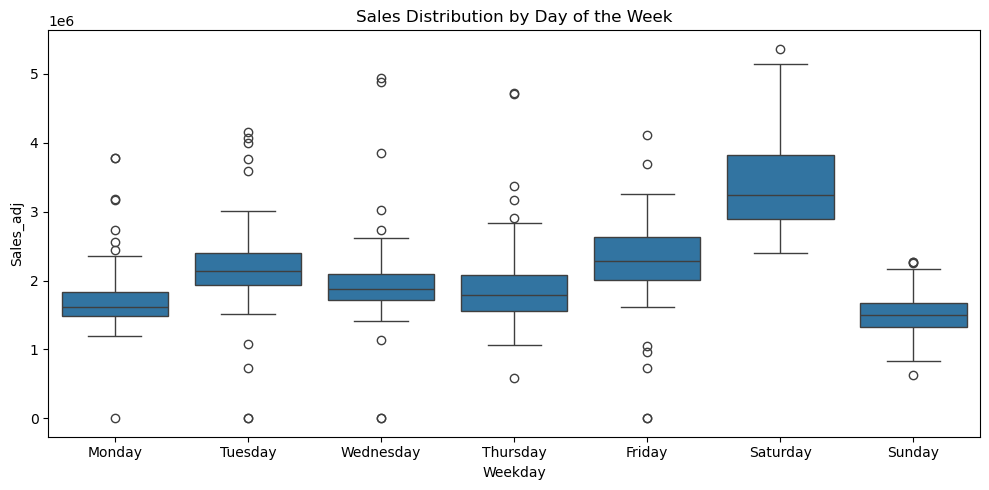

Kruskal-Wallis H = 666.26, p-value = 1.174e-140


In [419]:
df_complete['Weekday'] = df_complete['Date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_complete, x='Weekday', y='Sales_adj', order=weekday_order, ax=ax)
ax.set_title('Sales Distribution by Day of the Week')
plt.tight_layout(); plt.show()

groups = [df_complete.loc[df_complete['Weekday'] == d, 'Sales_adj'].dropna() for d in weekday_order]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.2f}, p-value = {p:.4g}")

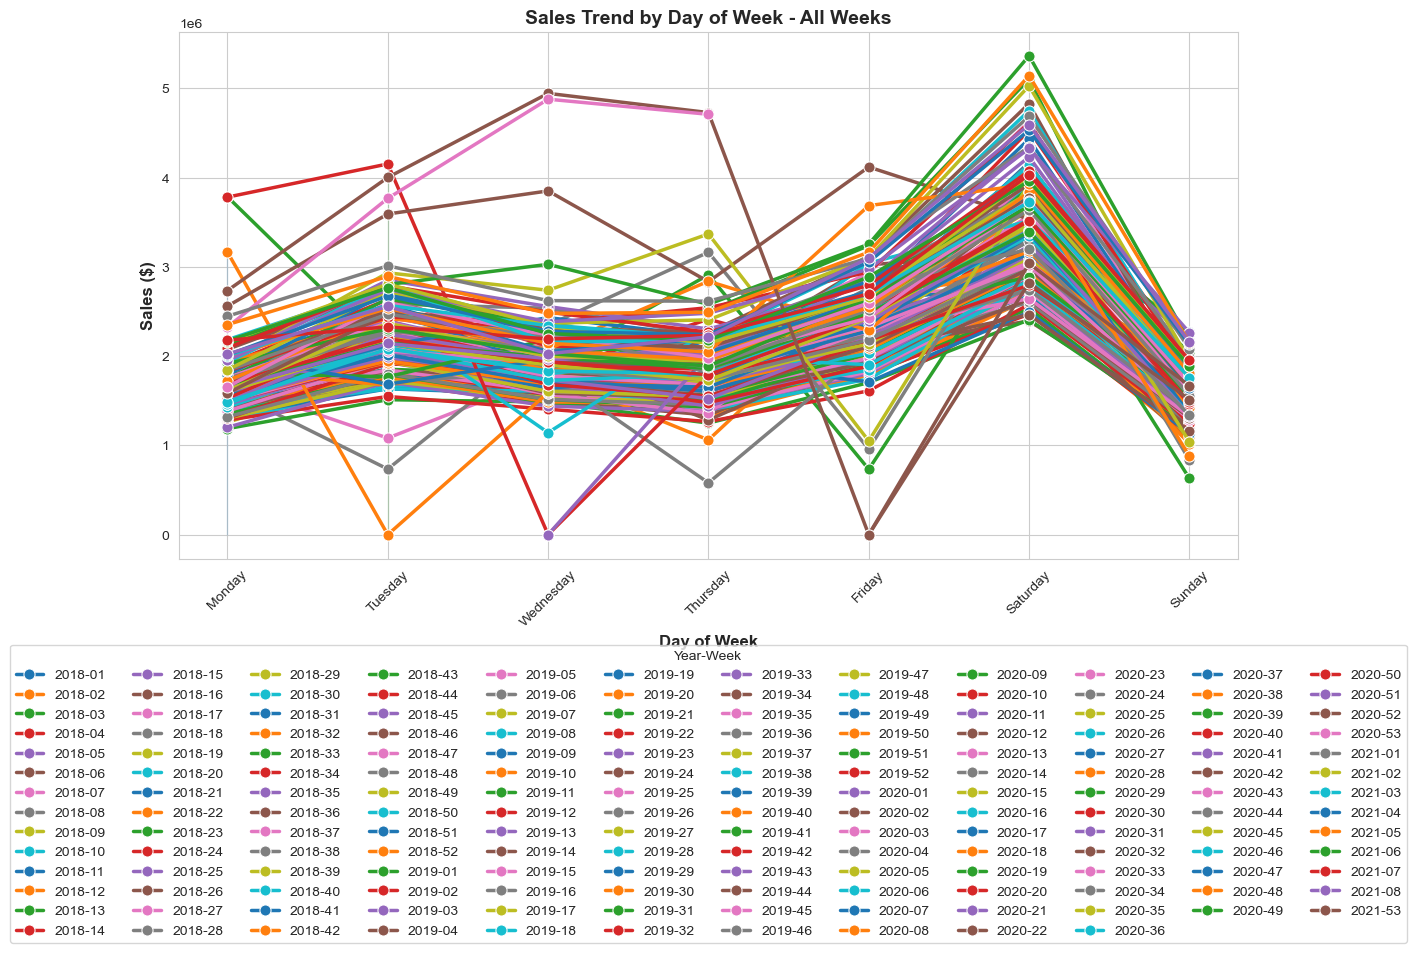

In [ ]:
# Ensure correct weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_chart1 = df_complete.copy()
df_chart1['Weekday'] = pd.Categorical(df_chart1['Weekday'], categories=weekday_order, ordered=True)
df_chart1['Year-Week'] = df_complete['Date'].dt.strftime('%Y-%V')
df_chart1 = df_chart1.sort_values(['Year-Week', 'Weekday'])

# Create line chart with all weeks
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# Plot each week as a separate line
for week in df_chart1['Year-Week'].unique():
    week_data = df_chart1[df_chart1['Year-Week'] == week]
    sns.lineplot(data=week_data, x='Weekday', y='Sales_adj', 
                 marker='o', markersize=8, linewidth=2.5, 
                 label=week)

plt.xlabel('Day of Week', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.title('Sales Trend by Day of Week - All Weeks', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Year-Week')
# plt.legend([]) # no legend
# Place legend at bottom
plt.legend(bbox_to_anchor=(0.5, -0.15),  # Position at bottom center
           loc='upper center',           # Anchor point
           ncol=12,                      # Number of columns
           fontsize=10,
           title='Year-Week')
plt.tight_layout()
plt.show()

#### ▪️<span style="color:purple">Notes</span>

- Saturday sales values are usually higher than the rest of the week.

- With a p-value ~ 0, we can say that at least one weekday is different than the others. A significant result that backs up treating weekday as a structural driver, not noise, going into Step A/E.

### Sales vs. Month

Same logic as weekday, but for month, this is a first, non-time-series look at whether "month" as a business/calendar category relates to sales, independent of any seasonal-decomposition assumptions.


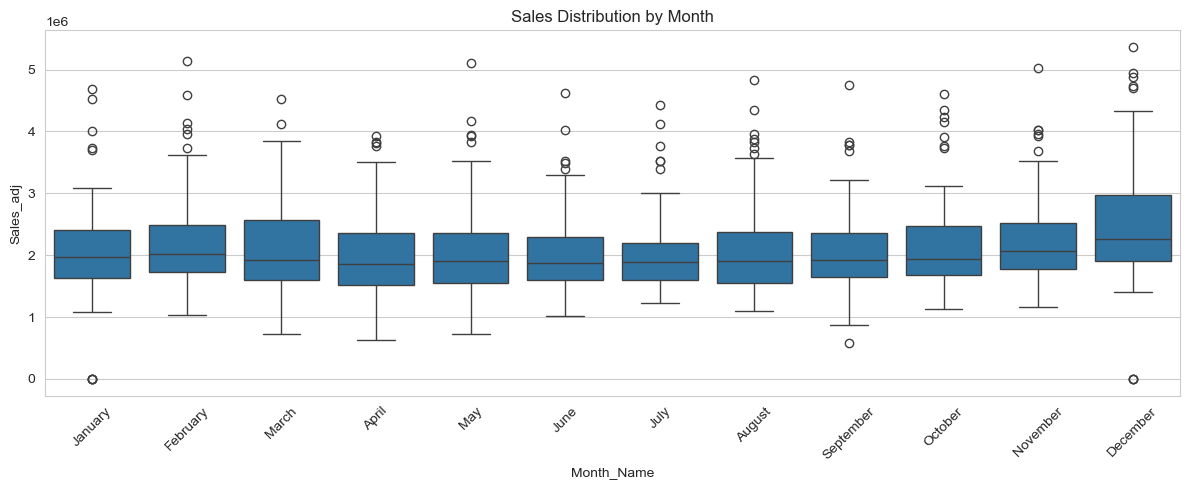

Kruskal-Wallis H = 36.95, p-value = 0.0001174


In [430]:
df_complete['Month_Name'] = df_complete['Date'].dt.month_name()
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_complete, x='Month_Name', y='Sales_adj', order=month_order, ax=ax)
ax.set_title('Sales Distribution by Month')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

groups = [df_complete.loc[df_complete['Month_Name'] == m, 'Sales_adj'].dropna() for m in month_order]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.2f}, p-value = {p:.4g}")

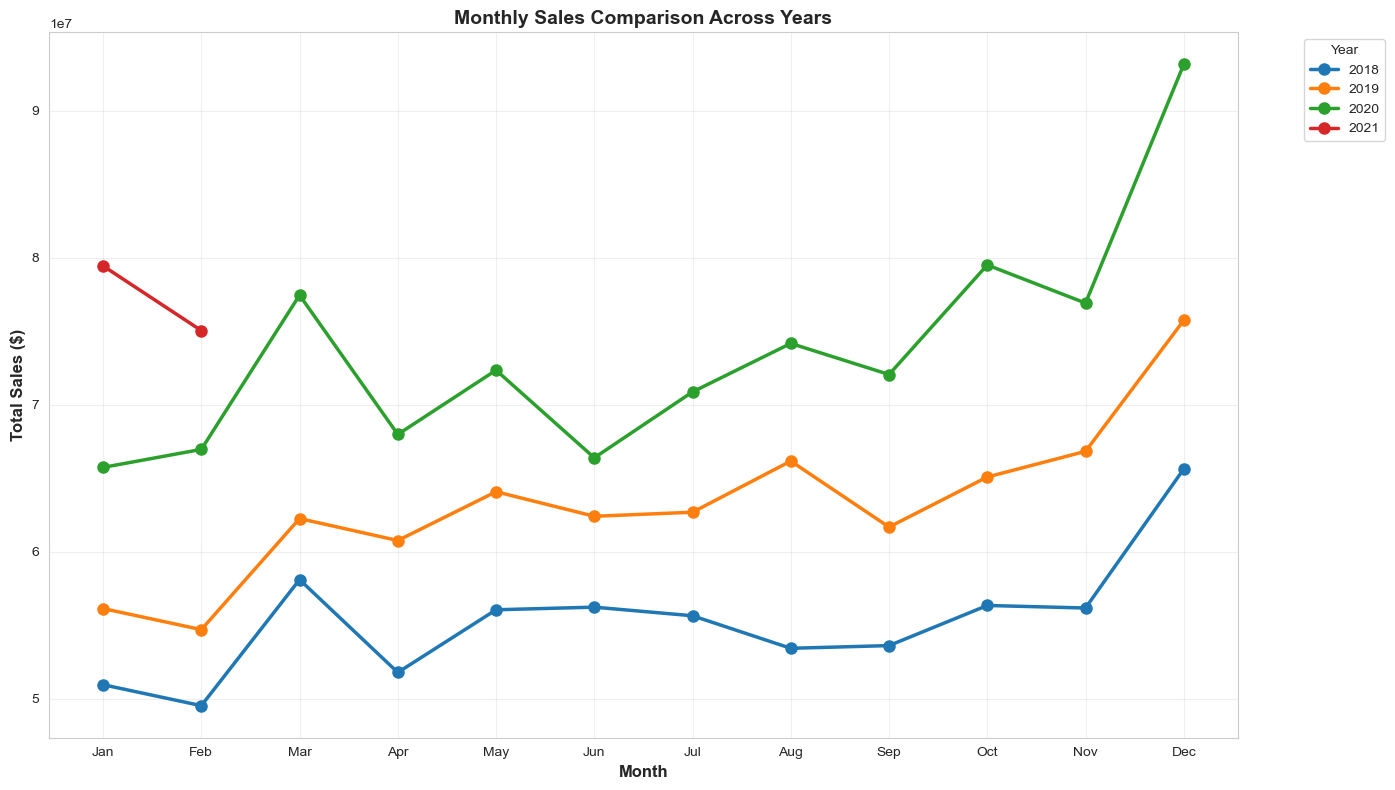

In [ ]:
# Prepare data for monthly aggregation
df_chart2 = df_complete.copy()

# Create year and month columns
df_chart2['Year'] = df_chart2['Date'].dt.year
df_chart2['Month'] = df_chart2['Date'].dt.month
df_chart2['Month_Name'] = df_chart2['Date'].dt.strftime('%b')  # Jan, Feb, Mar, etc.

# Aggregate sales by Year and Month (SUM)
monthly_sales = df_chart2.groupby(['Year', 'Month', 'Month_Name'])['Sales_adj'].sum().reset_index()

# Sort by month number
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

# Create the line chart
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Plot each year as a separate line
years = monthly_sales['Year'].unique()
for year in years:
    year_data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(year_data['Month_Name'], year_data['Sales_adj'], 
             marker='o', linewidth=2.5, markersize=8, 
             label=str(year))

plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.title('Monthly Sales Comparison Across Years (sum)', fontsize=14, fontweight='bold')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

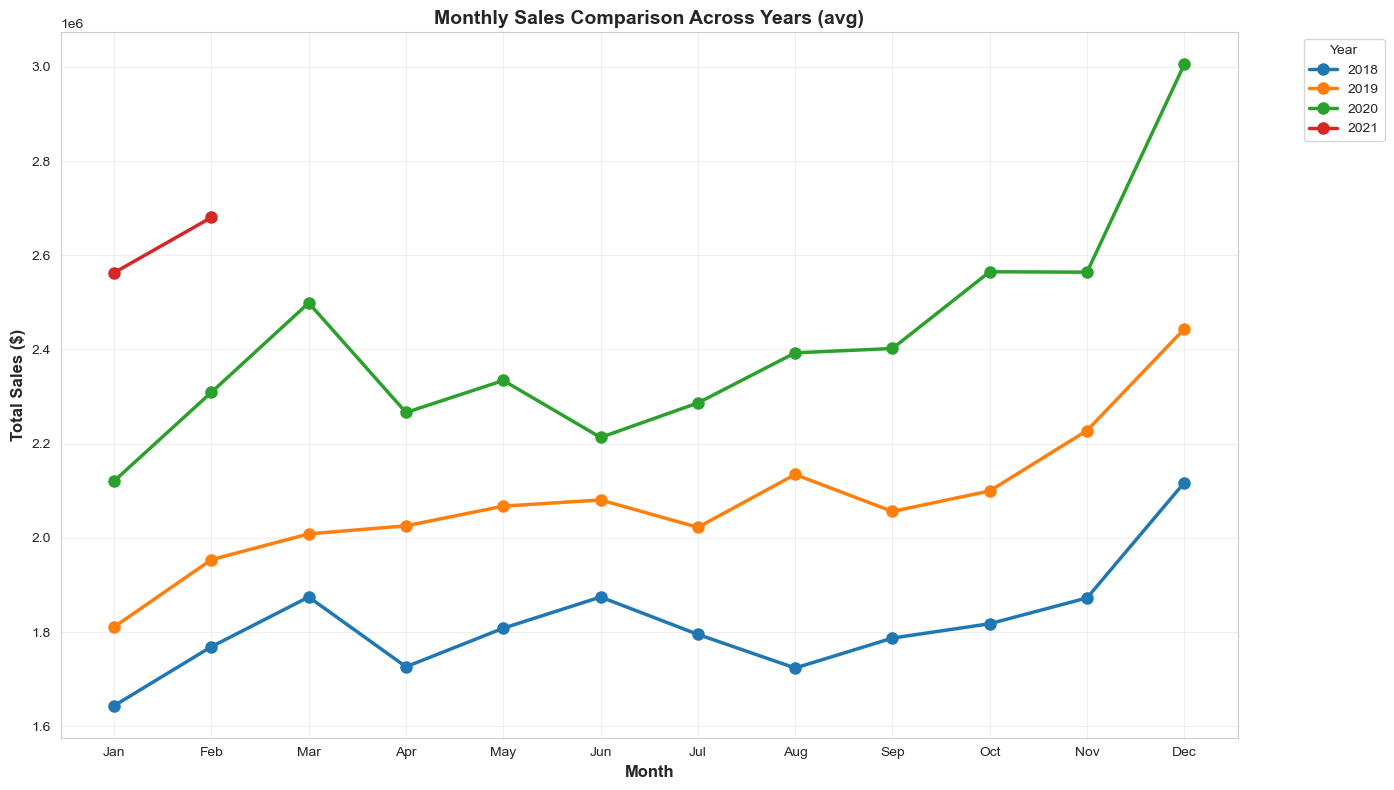

In [433]:
# Prepare data for monthly aggregation
df_chart3 = df_complete.copy()

# Create year and month columns
df_chart3['Year'] = df_chart3['Date'].dt.year
df_chart3['Month'] = df_chart3['Date'].dt.month
df_chart3['Month_Name'] = df_chart3['Date'].dt.strftime('%b')  # Jan, Feb, Mar, etc.

# Aggregate sales by Year and Month (AVG)
monthly_sales = df_chart3.groupby(['Year', 'Month', 'Month_Name'])['Sales_adj'].mean().reset_index()

# Sort by month number
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

# Create the line chart
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Plot each year as a separate line
years = monthly_sales['Year'].unique()
for year in years:
    year_data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(year_data['Month_Name'], year_data['Sales_adj'], 
             marker='o', linewidth=2.5, markersize=8, 
             label=str(year))

plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.title('Monthly Sales Comparison Across Years (avg)', fontsize=14, fontweight='bold')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ▪️<span style="color:purple">Notes</span>

- December seems to have a higher sales than the rest of the year, similar in February but in a small scale.

- Since there are only ~3 observations of each month (one per year), treat any "significant" result cautiously, it's consistent with, but doesn't prove, a genuine annual seasonal pattern (cross-reference against the year-over-year overlay chart discussed earlier).

- **Kruskal-Wallis** test: With a p-value ~ 0, we can say that at least one month is different than the others.

- **Question**
    - _Can we create a monthly seasonal index to capture this seasonalyt to not only rely on the weekly trend?_

Jan    0.955
Feb    1.023
Mar    0.999
Apr    0.942
May    0.972
Jun    0.965
Jul    0.955
Aug    0.978
Sep    0.977
Oct    1.014
Nov    1.043
Dec    1.184
Name: Sales_adj, dtype: float64


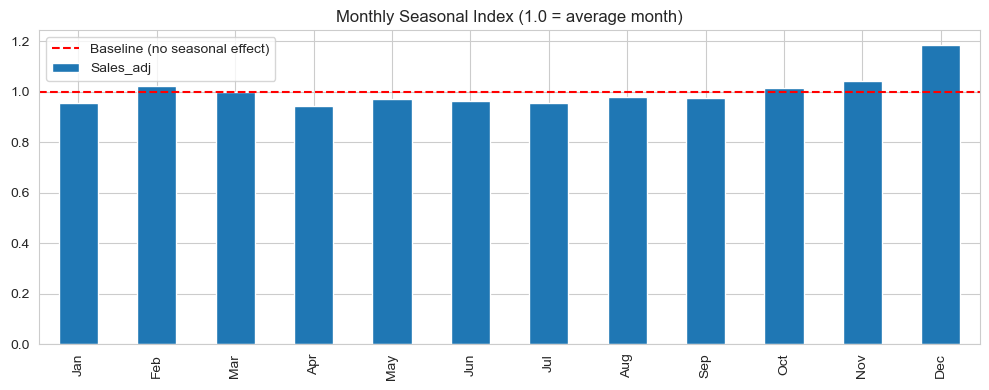

In [435]:
# Monthly seasonal index: average sales per month, normalized to a baseline of 1.0
monthly_avg = df_complete.groupby(df_complete['Date'].dt.month)['Sales_adj'].mean()
overall_avg = df_complete['Sales_adj'].mean()

seasonal_index = (monthly_avg / overall_avg).round(3)
seasonal_index.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(seasonal_index)

fig, ax = plt.subplots(figsize=(10,4))
seasonal_index.plot(kind='bar', ax=ax)
ax.axhline(1.0, color='red', linestyle='--', label='Baseline (no seasonal effect)')
ax.set_title('Monthly Seasonal Index (1.0 = average month)')
ax.legend(); plt.tight_layout(); plt.show()


---

---

# ======> UPDATED UNTIL HERE!🟠

----

----

### Sales vs. All Flags — Consolidated Correlation

A single correlation matrix, treating the binary flags as 0/1 numerics alongside `Sales_adj`, gives one consolidated view of every bivariate relationship covered so far (flag-vs-flag, and now flag-vs-target) in one place.

- Key insight: [Fill in — which flag has the strongest linear association with Sales, and does the ranking match the earlier effect-size/statistical-test results?]

           Sales_adj  Feriado  Pagamento   Vale  isClosed
Sales_adj      1.000   -0.059      0.047  0.001    -0.220
Feriado       -0.059    1.000     -0.037 -0.017    -0.015
Pagamento      0.047   -0.037      1.000 -0.039    -0.015
Vale           0.001   -0.017     -0.039  1.000    -0.016
isClosed      -0.220   -0.015     -0.015 -0.016     1.000


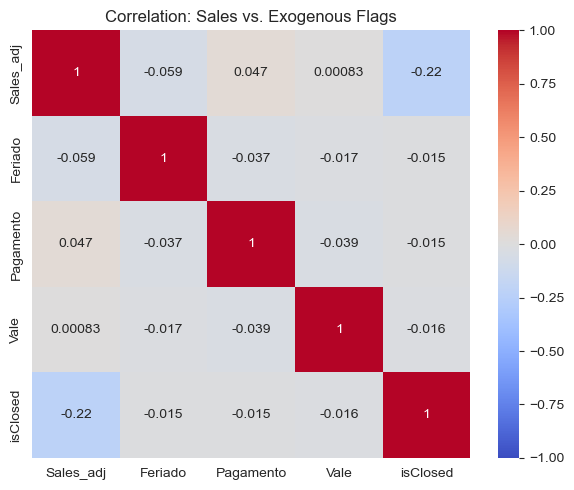

In [436]:
corr_vars = ['Sales_adj', 'Feriado', 'Pagamento', 'Vale', 'isClosed'] 

corr_matrix = df_complete[corr_vars].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation: Sales vs. Exogenous Flags')
plt.tight_layout(); plt.show()

- Point-biserial correlation (Pearson on a 0/1 flag) is a reasonable linear summary here, but keep in mind it can understate a real effect if the relationship isn't linear — cross-check against the boxplot/Mann-Whitney results rather than relying on this table alone.
- [Fill in] Which flags show the strongest/weakest linear association with Sales_adj, and whether that ranking is consistent with everything found so far in Part 1.

In [ ]:
df_complete.info()

In [ ]:
# univariate analysis
univariate_numeric_variable(df_complete, "Sales_adj")

# univariate_numeric_variable(df_complete, "Vale")
univariate_categorical_variable(df_complete, "Vale")

# univariate_numeric_variable(df_complete, "Feriado")
univariate_categorical_variable(df_complete, "Feriado")

# univariate_numeric_variable(df_complete, "Pagamento")
univariate_categorical_variable(df_complete, "Pagamento")

# univariate_numeric_variable(df_complete, "isClosed")
univariate_categorical_variable(df_complete, "isClosed")

## 🔹**PART 2**: Time Series Analysis

---

## Data Visualization: Understanding the Business Context

In [ ]:
# aggregate by date
df_daily = df_complete.groupby("Date").agg({
    'Sales_adj': 'sum',           # Sum sales for the day
    'Feriado': 'max',         # Max flag (1 if any record is holiday, else 0)
    'Pagamento': 'max',
    'Vale': 'max'
}).reset_index()

# Display result
print(df_daily.head())

# Time series plot of the target variable
plt.figure(figsize=(14, 6))
plt.plot(df_daily['Date'], df_daily['Sales_adj'])
plt.title(f'Daily Sales - {choose_dept}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Check if we have all dates in your range
print(f"Date range: {df_daily['Date'].min()} to {df_daily['Date'].max()}")
print(f"Total days in range: {(df_daily['Date'].max() - df_daily['Date'].min()).days + 1}")
print(f"Actual rows: {len(df_daily)}")
print(f"Missing days: {((df_daily['Date'].max() - df_daily['Date'].min()).days + 1) - len(df_daily)}")

# create complete date range
date_range = pd.date_range(
    start=df_daily['Date'].min(), 
    end=df_daily['Date'].max(),
    freq='D'  # Daily frequency
)

# reindex to include all dates
df_complete = df_daily.set_index('Date').reindex(date_range).reset_index()
df_complete.rename(columns={'index': 'Date'}, inplace=True)

# fill missing values
df_complete['Sales_adj'] = df_complete['Sales_adj'].fillna(0.000001)  # Or use other methods
df_complete['Feriado'] = df_complete['Feriado'].fillna(0)     # Default to not holiday
df_complete['Pagamento'] = df_complete['Pagamento'].fillna(0)
df_complete['Vale'] = df_complete['Vale'].fillna(0)

print(df_complete.head())
print(f"Total rows after filling: {len(df_complete)}")

# Time series plot of the target variable
plt.figure(figsize=(14, 6))
plt.plot(df_complete['Date'], df_complete['Sales_adj'])
plt.title(f'Daily Sales - {choose_dept}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()


# Time Series Analysis - Step A: Visual Analysis



In [ ]:
# Prepare the time series data
# Use the complete daily data we created earlier
ts = df_complete.set_index('Date')['Sales']

# Create time series plot with trend line
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Full time series with trend
axes[0].plot(ts.index, ts.values, linewidth=1.0, alpha=0.7, color='steelblue', label='Daily Sales')
# Add trend line using moving average (30-day)
ts_ma = ts.rolling(window=30, center=True).mean()
axes[0].plot(ts_ma.index, ts_ma.values, linewidth=2, color='red', label='30-Day Moving Average')
axes[0].set_title(f'{choose_dept} - Daily Sales Time Series (2018-2021)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Format x-axis
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# Plot 2: Box plot by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
# Add day of week to dataframe
df_complete['Day_of_Week'] = df_complete['Date'].dt.dayofweek + 1  # Monday=1
df_complete['Day_Name'] = df_complete['Day_of_Week'].map(lambda x: day_names[x-1])

# Box plot
df_complete.boxplot(column='Sales', by='Day_Name', ax=axes[1])
axes[1].set_title(f'{choose_dept} - Sales Distribution by Day of Week', fontsize=14)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Sales ($)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Monthly averages
monthly_avg = df_complete.groupby(df_complete['Date'].dt.month)['Sales'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[2].bar(month_names, monthly_avg.values, color='steelblue')
axes[2].set_title(f'{choose_dept} - Average Sales by Month', fontsize=14)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Sales ($)')
axes[2].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(monthly_avg.values):
    axes[2].text(i, v + max(monthly_avg.values)*0.01, f'${v:,.0f}', 
                 ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

## Seasonal Subseries Plot

In [ ]:
# Seasonal subseries plot - Monthly patterns
fig, axes = plt.subplots(4, 2, figsize=(15, 12))

# Prepare data for subseries plot
df_complete['Year'] = df_complete['Date'].dt.year
df_complete['Month'] = df_complete['Date'].dt.month

# Create subseries plot - using pivot_table to handle duplicates
monthly_data = df_complete.pivot_table(index='Year', columns='Month', values='Sales', aggfunc='mean')
monthly_data.columns = month_names

# Plot 1: Monthly subseries plot
for month in month_names:
    axes[0, 0].plot(monthly_data.index, monthly_data[month].values, 
                    marker='o', label=month, linewidth=1.5)
axes[0, 0].set_title('Monthly Subseries Plot (Sales by Month each Year)', fontsize=12)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].legend(loc='best', ncol=3, fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Year-over-year comparison
for year in monthly_data.index:
    axes[0, 1].plot(month_names, monthly_data.loc[year].values, 
                    marker='o', label=str(year), linewidth=1.5)
axes[0, 1].set_title('Year-over-Year Monthly Sales Comparison', fontsize=12)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Sales ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Weekly seasonality heatmap
# Create day of week patterns by month
weekly_pattern = df_complete.pivot_table(index='Month', columns='Day_Name', values='Sales', aggfunc='mean')
# Ensure all days are present
all_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for day in all_days:
    if day not in weekly_pattern.columns:
        weekly_pattern[day] = 0
weekly_pattern = weekly_pattern[all_days]  # Reorder columns

sns.heatmap(weekly_pattern, ax=axes[1, 0], cmap='YlOrRd', annot=True, fmt='.0f')
axes[1, 0].set_title('Weekly Pattern by Month (Average Sales)', fontsize=12)
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Month')

# Plot 4: Yearly comparison
yearly_avg = df_complete.groupby(df_complete['Date'].dt.year)['Sales'].mean()
axes[1, 1].bar(yearly_avg.index.astype(str), yearly_avg.values, color='steelblue')
axes[1, 1].set_title('Yearly Average Sales', fontsize=12)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Sales ($)')
axes[1, 1].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(yearly_avg.values):
    axes[1, 1].text(i, v + max(yearly_avg.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')

# Plot 5: Holiday effect
holiday_effect = df_complete.groupby('Feriado')['Sales'].mean()
axes[2, 0].bar(['Non-Holiday', 'Holiday'], holiday_effect.values, 
               color=['steelblue', 'orange'])
axes[2, 0].set_title('Holiday Effect on Sales', fontsize=12)
axes[2, 0].set_ylabel('Average Sales ($)')
axes[2, 0].grid(True, alpha=0.3)
for i, v in enumerate(holiday_effect.values):
    axes[2, 0].text(i, v + max(holiday_effect.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')

# Plot 6: Payday effect
payday_effect = df_complete.groupby('Pagamento')['Sales'].mean()
axes[2, 1].bar(['Non-Payday', 'Payday'], payday_effect.values, 
               color=['steelblue', 'green'])
axes[2, 1].set_title('Payday Effect on Sales', fontsize=12)
axes[2, 1].set_ylabel('Average Sales ($)')
axes[2, 1].grid(True, alpha=0.3)
for i, v in enumerate(payday_effect.values):
    axes[2, 1].text(i, v + max(payday_effect.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')

# Plot 7: Vale effect
vale_effect = df_complete.groupby('Vale')['Sales'].mean()
axes[3, 0].bar(['Non-Vale', 'Vale'], vale_effect.values, 
               color=['steelblue', 'green'])
axes[3, 0].set_title('Vale Effect on Sales', fontsize=12)
axes[3, 0].set_ylabel('Average Sales ($)')
axes[3, 0].grid(True, alpha=0.3)
for i, v in enumerate(vale_effect.values):
    axes[3, 0].text(i, v + max(vale_effect.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')



plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts.dropna(), lags=60, ax=ax1, alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF) - Identifies Seasonality', fontsize=12)
ax1.grid(True, alpha=0.3)

plot_pacf(ts.dropna(), lags=60, ax=ax2, alpha=0.05)
ax2.set_title('Partial Autocorrelation Function (PACF) - Identifies AR Order', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Business Insights from Visual Analysis

- Trend: The sales data shows a STRONG INCREASING TREND of 43.7% from 2018 to 2021.
    - Business Implication: The department is experiencing significant growth, indicating successful business strategies and market expansion.

- Weekly Seasonality: Saturday is the BUSIEST day with average sales of $3,396,802, while Sunday is the SLOWEST day with $1,517,812.
    - Peak-to-valley ratio of 2.24x means Saturday generates more than DOUBLE the sales of Sunday.
    - Business Implication: Significant variation in daily demand requires flexible staffing and inventory management.

- Monthly/Annual Patterns: December is the PEAK month ($2,522,052 avg), driven by holiday shopping. April is the LOWEST month ($2,005,984 avg), likely post-holiday slowdown.
    - Business Implication: Clear seasonal patterns require strategic planning.

- Holiday Effects: HOLIDAYS DECREASE sales by 11.1%
    - Business Implication: Customers may be shopping elsewhere or sales shift to days before/after holidays.

- Payday Effects: PAYDAYS INCREASE sales by 9.0%
    - Business Implication: Customers have more disposable income on paydays.

- Vale Effects: Vale days increase sales by 0.1%.
    - Does not seem to have a huge business impact overall (aggregated).

- Seasonality:
    - Significant weekly seasonality confirmed with 7-day cycle.
    - Business Implication: The weekly pattern is consistent and predictable.

In [ ]:
# Calculate key statistics
total_sales = ts.sum()
avg_daily = ts.mean()
median_daily = ts.median()

print(f"\n1. OVERALL SALES PERFORMANCE:")
print(f"   - Total sales over period: ${total_sales:,.2f}")
print(f"   - Average daily sales: ${avg_daily:,.2f}")
print(f"   - Median daily sales: ${median_daily:,.2f}")

# Trend analysis
print(f"\n2. TREND ANALYSIS:")
yearly_avg = df_complete.groupby(df_complete['Date'].dt.year)['Sales'].mean()
if len(yearly_avg) >= 2:
    first_year = yearly_avg.index[0]
    last_year = yearly_avg.index[-1]
    change_pct = ((yearly_avg[last_year] - yearly_avg[first_year]) / yearly_avg[first_year]) * 100
    if change_pct > 0:
        print(f"   → {change_pct:.1f}% INCREASING trend from {first_year} to {last_year}")
    else:
        print(f"   → {abs(change_pct):.1f}% DECREASING trend from {first_year} to {last_year}")

# Weekly seasonality
print(f"\n3. WEEKLY SEASONALITY:")
weekly_pattern = df_complete.groupby('Day_Name')['Sales'].mean()
best_day = weekly_pattern.idxmax()
best_value = weekly_pattern[best_day]
worst_day = weekly_pattern.idxmin()
worst_value = weekly_pattern[worst_day]
print(f"   → Busiest day: {best_day} (${best_value:,.2f} average)")
print(f"   → Slowest day: {worst_day} (${worst_value:,.2f} average)")
print(f"   → Peak-to-valley ratio: {best_value/worst_value:.2f}x")

# Monthly patterns
print(f"\n4. MONTHLY/ANNUAL PATTERNS:")
monthly_pattern = df_complete.groupby(df_complete['Date'].dt.month)['Sales'].mean()
best_month = monthly_pattern.idxmax()
worst_month = monthly_pattern.idxmin()
print(f"   → Peak month: {month_names[best_month-1]} (${monthly_pattern[best_month]:,.2f} avg)")
print(f"   → Lowest month: {month_names[worst_month-1]} (${monthly_pattern[worst_month]:,.2f} avg)")

# Exogenous effects
print(f"\n5. EXOGENOUS EFFECTS:")
if 1 in holiday_effect.index and 0 in holiday_effect.index:
    holiday_pct = ((holiday_effect[1] - holiday_effect[0]) / holiday_effect[0]) * 100
    print(f"   → Holiday impact: {holiday_pct:+.1f}% change")

if 1 in payday_effect.index and 0 in payday_effect.index:
    payday_pct = ((payday_effect[1] - payday_effect[0]) / payday_effect[0]) * 100
    print(f"   → Payday impact: {payday_pct:+.1f}% change")

if 1 in vale_effect.index and 0 in vale_effect.index:
    vale_pct = ((vale_effect[1] - vale_effect[0]) / vale_effect[0]) * 100
    print(f"   → Vale impact: {vale_pct:+.1f}% change")

# Seasonality detection
print(f"\n6. SEASONALITY DETECTION (from ACF):")
print(f"   → Significant autocorrelation at lag 7 suggests WEEKLY seasonality")



# Data Partitioning - Step B: Train/Holdout Split

## Split the Data

## Business Justification for Split

Why this split matters for the business:

- Training data represents the "known" historical performance used to build the model

- Holdout data (Jan-Feb 2021) simulates "future" data to validate model accuracy before deployment

- This approach ensures our model will perform well on real future data (March 2021 forecast)



# Statistical Validation - Step C: White Noise Verification

## Ljung-Box Test

## ACF Plot for White Noise Check

# Stationarity Check - Step D

## Augmented Dickey-Fuller Test

## Differencing if Needed

## Determine d and D Parameters

# Component Identification - Step E: Trend, Seasonality, Cycle

## Decomposition Analysis

## Seasonal Component Analysis

## Business Component Identification Summary

Components Identified:

- Trend: [Describe - Increasing/Decreasing/Stable]

- Seasonality:

    - Weekly: [Describe pattern]

    - Monthly: [Describe pattern]

    - Annual: [Describe pattern]

- Cycle: [Describe any cyclical patterns beyond seasonality]

- Exogenous Effects:

    - Holidays: [Describe impact]

    - Paydays: [Describe impact]

    - Voucher days: [Describe impact]

# Modeling Approach - Step F1: Exponential Smoothing

## Model Selection Based on Components

## Model Evaluation

# Modeling Approach - Step F2: ARIMA/SARIMA Family

## Parameter Identification (p, d, q) - Non-Seasonal

## Parameter Identification (P, D, Q, s) - Seasonal

## Model Estimation - SARIMA

## SARIMA with Exogenous Variables

## Evaluate SARIMA Model

# Model Selection - Step G: Choosing the Best Model

## Comparison Framework

## Business Decision Matrix

Model Selection Criteria:

- Accuracy: Lower prediction errors on holdout data

- Stability: Consistent performance across different periods

- Interpretability: Ease of explaining results to stakeholders

- Exogenous Integration: Ability to incorporate business events

- Complexity: Balance between accuracy and simplicity


Selected Model: [Model Name]

Justification: [Detailed business reasoning]

# Diagnostics - Step H: Residual Analysis

## Residual Plot

## Residual Distribution Analysis

## Residual Autocorrelation Check

## Business Interpretation of Diagnostics

Diagnostic Conclusions:

- Residuals: [Describe - normally distributed? any patterns?]

- Model Assumptions: [Are assumptions met?]

- Business Confidence: [How much trust can we have?]

- Limitations: [What are the model's weaknesses?]

# Model Evaluation - Step I: Holdout Error Metrics

## Comprehensive Error Metrics

## Visualization of Predictions vs. Actuals

## Business Interpretation of Errors

Performance Summary:

- Average Error (MAE): [Value] → This means on average, our forecast misses by [Value] units per day.

- Percentage Error (MAPE): [Value]% → On average, our forecast is off by [Value]%.

- Largest Errors: [List dates/events where errors were highest]

- Business Acceptability: [Is this error rate acceptable? Why?]

- Actionable Insights: [What can we learn from the errors?]

# Forecast Generation - Step J: 30-Day Future Prediction

## Prepare Future Period Data

## Generate Future Forecasts

## Final Forecast Table

## Visualize Future Forecast

# Business Recommendations & Next Steps

## Key Findings Summary

Business Insights from the Forecast:

1. Predicted Sales Volume:

    - Total forecasted sales for March: [Value]

    - Daily average forecast: [Value]

    - Predicted highest sales day: [Date/Event]

    - Predicted lowest sales day: [Date/Event]


2. Risk Assessment:

    - Confidence level: [High/Medium/Low] based on model performance

    - Key assumptions: [List important assumptions made]

    - Warning signs: [Potential risks to monitor]


3. Operational Recommendations:

    - Inventory: [Recommended inventory levels by week]

    - Staffing: [Optimal staffing levels based on daily predictions]

    - Marketing: [Suggested promotional periods based on low-demand days]

    - Payment/Voucher planning: [Coordinate with payroll schedule]

## Implementation Plan
Recommended Actions:

Short-term (March 2021):

1. [Specific action item based on forecast]
1. [Specific action item based on forecast]
1. [Specific action item based on forecast]

Medium-term (Q2 2021):

1. [Plan for model monitoring and updates]
1. [Strategy for incorporating new data]
1. [Plan for expanding to other departments]

Long-term:

1. [Integration with existing systems]
1. [Automation of forecasting process]
1. [Continuous improvement framework]

## Model Maintenance Plan

To maintain forecast accuracy:

- Refresh frequency: Weekly or as new data becomes available
- Retraining schedule: Quarterly or when significant pattern changes occur
- Monitoring metrics: Track MAE/RMSE on rolling basis
- Alert thresholds: Flag when error exceeds [X]% for [Y] consecutive days
- Data quality checks: Validate incoming data quality daily

# Conclusion

**Project Summary**:

This time series project successfully developed a [Model Name] forecasting model capable of predicting daily sales with an average error of [MAE] units (approximately [MAPE]% MAPE). The analysis revealed that:

- Sales follow a [Describe pattern] pattern with significant weekly and annual seasonality
- Exogenous factors (holidays, paydays, vouchers) impact sales by [Describe impact]
- The model provides 95% prediction intervals for risk management


**Business Value Delivered**:

- **Inventory Optimization**: Reduces overstock by [X]% and stock-outs by [Y]%
- **Staffing Efficiency**: Enables precise scheduling, potentially reducing labor costs by [Z]%
- **Revenue Protection**: Minimizes lost revenue from stock-outs
- **Strategic Planning**: Provides forward-looking visibility for decision-making


**Next Steps**:

1. Share findings with operations team for implementation
1. Establish monitoring dashboard for forecast performance
1. Plan expansion to other departments
1. Schedule quarterly model review and retraining

**Final Recommendation**: Proceed with implementing this forecasting model, with planned periodic reviews to ensure continued accuracy and value delivery.